## Objetivo del Proyecto
Predecir el **motivo de abandono** de clientes del segmento objetivo del banco,
clasificando en 6 categorías (0-5).

CARGA Y EXPLORACIÓN INICIAL

Universo (target)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga de csvs para exploración

universo = pd.read_csv('data/universo.csv')


Exploración csv universo

In [2]:
universo.head()

,ID,target,periodo
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5


In [3]:
universo.shape

(535943, 3)

Código	Descripción del motivo de abandono:

-0	Cliente inactivo o con bajo movimiento.

-1	Reducción de saldos activos o pasivos.

-2	Cancelación voluntaria de productos.

-3	Comportamiento crediticio negativo.

-4	Cambio de segmento o migración a otro perfil.

-5 Otros motivos


**Importancia:** Poder predecir el motivo de abandono de los clientes más importantes para ejecutar estrategias de retención de clientes, buscando generar valor.


In [4]:
universo['target'].value_counts()

target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64

In [5]:
universo['target'].value_counts(normalize=True).sort_index() * 100

target
0    86.590365
1     8.801496
2     1.106274
3     0.631784
4     1.286144
5     1.583937
Name: proportion, dtype: float64

In [6]:
universo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535943 entries, 0 to 535942
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ID       535943 non-null  object
 1   target   535943 non-null  int64 
 2   periodo  535943 non-null  object
dtypes: int64(1), object(2)
memory usage: 12.3+ MB


In [7]:
universo['target'].describe()

count    535943.000000
mean          0.259737
std           0.850548
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: target, dtype: float64

In [8]:
universo.isnull().sum()


ID         0
target     0
periodo    0
dtype: int64

In [9]:
universo['periodo'].nunique()


6

In [10]:
universo['ID'].nunique()

535943

###**universo.csv** - Tabla Target
- **Granularidad**: 1 registro por (ID, periodo)
- **Registros**: 535,943 clientes
- **Contiene**: Variable objetivo (target)
- **Target desbalanceado**: 86.6% clase 0
- **Sin valores nulos o duplicados**
- **Periodo viene a ser fecha de extracción de la data**




In [11]:
base_clientes = pd.read_csv('data/base_clientes.csv')
base_consumos = pd.read_csv('data/base_consumos.csv')
base_creditos = pd.read_csv('data/base_saldos_creditos.csv')
base_cuentas = pd.read_csv('data/base_saldos_cuentas.csv')

In [12]:
base_clientes.head()

,ID,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No


In [13]:
base_clientes.shape

(809579, 14)

In [14]:
D1=base_clientes['ID'].duplicated().sum()
print(D1)

0


In [15]:
clientes_sin_target = pd.merge(
    universo, 
    base_clientes, 
    on='ID', 
    how='right', 
    indicator=True
)

clientes_sin_target = clientes_sin_target[clientes_sin_target['_merge'] == 'right_only']

In [16]:
clientes_sin_target.head()

,ID,target,periodo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda,_merge
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,NaN,NaN,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No,right_only
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,NaN,NaN,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No,right_only
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,NaN,NaN,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No,right_only
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,NaN,NaN,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No,right_only
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,NaN,NaN,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No,right_only


In [17]:
clientes_sin_target.drop(['periodo','_merge'] , axis=1, inplace=True)


In [18]:
clientes_sin_target.shape

(273636, 15)

In [19]:
clientes_sin_target.head()

,ID,target,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,NaN,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,NaN,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,NaN,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,NaN,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,NaN,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No


In [20]:
universo.rename(columns={'periodo': 'periodo_universo'}, inplace=True)

# 1. Primer merge
df_combinado_1 = pd.merge(universo, base_clientes, on='ID', how='left')


In [21]:
df_combinado_1.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,No,No,Yes,No,No,No
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,No,No,Yes,No,No,No
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,No,No,Yes,No,No,No
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,No,No,Yes,Yes,Yes,No
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,No,No,Yes,No,No,No


**Procedemos a analizar base_consumos**

In [22]:
base_consumos.head()

,periodo,ID,mes,compra_supermercado,compra_restaurante,compra_salud,compra_transporte
0,period_9,a66d4bbb5278c8a586e03d81e1be8d3590060d8f37fb8c...,12,0.0000,0.0000,0.0000,3.9437
1,period_9,0d0a4fb4f1c98add65a45cf8882e1d81848502143f4ae2...,1,3.7397,3.3499,0.0000,0.0000
2,period_9,a5b9c4d7ae3dfe5cc1c0ca073b0cb0369e1389bfec5c56...,4,3.6273,3.9726,3.6655,4.4131
3,period_9,8a583965c827c377690b816c90246eaedc499f03a5f25f...,8,3.7855,4.8286,5.0000,4.5094
4,period_9,e53bf4249c7d6d573d532b8b0bad7ffe2fb203a4f00675...,7,2.6077,3.9344,1.3229,3.8061


In [23]:
base_consumos.shape

(3697738, 7)

In [24]:
D2=base_consumos['ID'].duplicated().sum()
print(D2)

3169010


In [25]:
base_consumos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3697738 entries, 0 to 3697737
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   periodo              object 
 1   ID                   object 
 2   mes                  int64  
 3   compra_supermercado  float64
 4   compra_restaurante   float64
 5   compra_salud         float64
 6   compra_transporte    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 197.5+ MB


In [26]:
base_consumos_agrupado = base_consumos.groupby('ID', as_index=False).agg({
    'periodo': 'max',               
    'mes': 'max',                    
    'compra_supermercado': ['sum','mean','max'],
    'compra_restaurante': ['sum','mean','max'],
    'compra_salud': ['sum','mean','max'],
    'compra_transporte': ['sum','mean','max']
})

base_consumos_agrupado.columns = ['_'.join(col).strip() for col in base_consumos_agrupado.columns]

base_consumos_agrupado.head()

,ID_,periodo_max,mes_max,compra_supermercado_sum,compra_supermercado_mean,compra_supermercado_max,compra_restaurante_sum,compra_restaurante_mean,compra_restaurante_max,compra_salud_sum,compra_salud_mean,compra_salud_max,compra_transporte_sum,compra_transporte_mean,compra_transporte_max
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,period_6,11,2.2460,1.123000,2.2460,0.0000,0.0000,0.0000,0.0000,0.000000,0.0000,2.6134,1.306700,2.6134
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,period_1,8,2.0298,1.014900,2.0298,0.0000,0.0000,0.0000,3.4227,1.711350,3.4227,0.0000,0.000000,0.0000
2,00007a4554cd3a350aec583adebe766eb0beef5684f3dd...,period_6,10,2.9017,0.483617,2.9017,0.0000,0.0000,0.0000,14.6370,2.439500,3.4955,15.4955,2.582583,3.3280
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,period_8,12,11.4409,3.813633,5.0000,3.3897,1.1299,3.3897,4.0202,1.340067,4.0202,0.0000,0.000000,0.0000
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,period_5,12,2.8701,0.574020,2.8701,5.7900,1.1580,2.9725,2.4001,0.480020,2.4001,5.5136,1.102720,2.8355


In [27]:
D3=base_consumos_agrupado['ID_'].duplicated().sum()
print(D3)

0


In [28]:
base_consumos_agrupado.rename(columns={'ID_':'ID'}, inplace=True)

In [29]:
base_consumos_agrupado.rename(columns={'periodo_max':'periodo_max_consumo','mes_max':'mes_max_consumo',}, inplace=True)

In [30]:
base_consumos_agrupado.head()

,ID,periodo_max_consumo,mes_max_consumo,compra_supermercado_sum,compra_supermercado_mean,compra_supermercado_max,compra_restaurante_sum,compra_restaurante_mean,compra_restaurante_max,compra_salud_sum,compra_salud_mean,compra_salud_max,compra_transporte_sum,compra_transporte_mean,compra_transporte_max
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,period_6,11,2.2460,1.123000,2.2460,0.0000,0.0000,0.0000,0.0000,0.000000,0.0000,2.6134,1.306700,2.6134
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,period_1,8,2.0298,1.014900,2.0298,0.0000,0.0000,0.0000,3.4227,1.711350,3.4227,0.0000,0.000000,0.0000
2,00007a4554cd3a350aec583adebe766eb0beef5684f3dd...,period_6,10,2.9017,0.483617,2.9017,0.0000,0.0000,0.0000,14.6370,2.439500,3.4955,15.4955,2.582583,3.3280
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,period_8,12,11.4409,3.813633,5.0000,3.3897,1.1299,3.3897,4.0202,1.340067,4.0202,0.0000,0.000000,0.0000
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,period_5,12,2.8701,0.574020,2.8701,5.7900,1.1580,2.9725,2.4001,0.480020,2.4001,5.5136,1.102720,2.8355


In [31]:
base_consumos_agrupado.shape

(528728, 15)

In [32]:
consumo_sin_target = pd.merge(
    universo, 
    base_consumos_agrupado, 
    on='ID', 
    how='right', 
    indicator=True
)

consumo_sin_target = consumo_sin_target[consumo_sin_target['_merge'] == 'right_only']

In [33]:
consumo_sin_target.shape

(179877, 18)

In [34]:
# 2. Segundo merge
df_combinado_2 = pd.merge(df_combinado_1, base_consumos_agrupado, on='ID', how='left')

In [35]:
df_combinado_2.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,...,compra_supermercado_max,compra_restaurante_sum,compra_restaurante_mean,compra_restaurante_max,compra_salud_sum,compra_salud_mean,compra_salud_max,compra_transporte_sum,compra_transporte_mean,compra_transporte_max
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,3.7176,7.0684,1.009771,3.7699,13.2421,1.891729,3.5967,8.4241,1.203443,3.3964
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,4.2738,5.9529,0.496075,3.8944,5.3682,0.447350,2.6862,36.3588,3.029900,3.7118
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,4.3384,30.6276,2.552300,4.3806,12.7509,1.062575,3.8907,26.7633,2.230275,3.2531


In [36]:
df_combinado_2.columns

Index(['ID', 'target', 'periodo_universo', 'edad', 'ingreso', 'anios_exp',
       'tipo_empleo', 'buro_de_credito', 'pago_nomina', 'tc', 'prest_per',
       'prest_veh_hip', 'cuenta_ahorro', 'ofer_prest_per', 'ofer_tc',
       'ofer_compra_deuda', 'periodo_max_consumo', 'mes_max_consumo',
       'compra_supermercado_sum', 'compra_supermercado_mean',
       'compra_supermercado_max', 'compra_restaurante_sum',
       'compra_restaurante_mean', 'compra_restaurante_max', 'compra_salud_sum',
       'compra_salud_mean', 'compra_salud_max', 'compra_transporte_sum',
       'compra_transporte_mean', 'compra_transporte_max'],
      dtype='object')

**Procedemos a analizar base_creditos para posteriormente hacer el 3er merge**

In [37]:
base_creditos.head()

,mes,ID,tipo_credito,tipo_producto,inst_fin,monto_saldo,dias_atraso,periodo
0,11,c844ef92b32ec94baaf565a3d22cfa20fd1544a0f8efab...,type_7,product_2,entity_2,3.4051,5.0,period_5
1,10,c817cb3a37a6b640304e87fafd7cd8569bfffb650a5aa3...,type_7,product_2,entity_1,3.4003,5.0,period_5
2,6,1d1f726d844c5a343cca1bbfd0c2b869559f5910772c5e...,type_7,product_2,entity_5,3.0592,5.0,period_5
3,6,7c77a3fd230db16988cb2e6ca23779c756f86895dfe254...,type_7,product_2,entity_2,2.8013,5.0,period_5
4,11,a8702fb4fbdcb735619d6fbd0a5fed46096cdaba80ea35...,type_7,product_2,entity_2,2.9850,5.0,period_5


In [38]:
base_creditos.shape

(11597785, 8)

In [39]:
D3=base_creditos['ID'].duplicated().sum()
print(D3)

11092088


In [40]:
base_creditos.rename(columns={'periodo':'periodo_credito','monto_saldo':'monto_saldo_credito'}, inplace=True)


In [41]:
base_creditos.head()

,mes,ID,tipo_credito,tipo_producto,inst_fin,monto_saldo_credito,dias_atraso,periodo_credito
0,11,c844ef92b32ec94baaf565a3d22cfa20fd1544a0f8efab...,type_7,product_2,entity_2,3.4051,5.0,period_5
1,10,c817cb3a37a6b640304e87fafd7cd8569bfffb650a5aa3...,type_7,product_2,entity_1,3.4003,5.0,period_5
2,6,1d1f726d844c5a343cca1bbfd0c2b869559f5910772c5e...,type_7,product_2,entity_5,3.0592,5.0,period_5
3,6,7c77a3fd230db16988cb2e6ca23779c756f86895dfe254...,type_7,product_2,entity_2,2.8013,5.0,period_5
4,11,a8702fb4fbdcb735619d6fbd0a5fed46096cdaba80ea35...,type_7,product_2,entity_2,2.9850,5.0,period_5


**Definimos clientes con creditos y que no esten en mi base principal universo**

In [42]:
creditos_sin_target = pd.merge(
    universo, 
    base_creditos, 
    on='ID', 
    how='right', 
    indicator=True
)

creditos_sin_target = creditos_sin_target[creditos_sin_target['_merge'] == 'right_only']


In [43]:
creditos_sin_target.head()


,ID,target,periodo_universo,mes,tipo_credito,tipo_producto,inst_fin,monto_saldo_credito,dias_atraso,periodo_credito,_merge
6613,448da2e95710b4559786a41a9d46ce3c9c5003f2f54e7f...,NaN,NaN,4,type_3,product_2,entity_2,3.6298,0.0,period_8,right_only
6614,448da2e95710b4559786a41a9d46ce3c9c5003f2f54e7f...,NaN,NaN,6,type_3,product_2,entity_2,3.5382,0.0,period_8,right_only
6615,4d731bdb9e96ac9ac9030b85f99ed2247aaafd5dfb88a2...,NaN,NaN,7,type_3,product_1,entity_3,3.9761,0.0,period_8,right_only
6616,04052f92be831b978a7ac9a3ace3255dcddb5528fc4fce...,NaN,NaN,11,type_3,product_1,entity_3,4.8949,0.0,period_8,right_only
6617,c0a2d813b7187cb9941474c78dfaa6f51aa180daf4ec7e...,NaN,NaN,12,type_3,product_1,entity_3,4.6378,0.0,period_8,right_only


In [44]:
creditos_sin_target.shape


(4028614, 11)

In [45]:
base_creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11597785 entries, 0 to 11597784
Data columns (total 8 columns):
 #   Column               Dtype  
---  ------               -----  
 0   mes                  int64  
 1   ID                   object 
 2   tipo_credito         object 
 3   tipo_producto        object 
 4   inst_fin             object 
 5   monto_saldo_credito  float64
 6   dias_atraso          float64
 7   periodo_credito      object 
dtypes: float64(2), int64(1), object(5)
memory usage: 707.9+ MB


In [46]:
# 1. Ordenamos por ID y monto_saldo_credito de mayor a menor
base_creditos_sorted = base_creditos.sort_values(['ID', 'monto_saldo_credito'], ascending=[True, False])

# 2️. Tomamos el registro con el MAYOR monto_saldo_credito por cliente
base_creditos_top = base_creditos_sorted.groupby('ID', as_index=False).first()[[
    'ID', 'tipo_credito', 'tipo_producto', 'inst_fin'
]]

# 3️. Calculamos las métricas agregadas
base_creditos_agg = base_creditos.groupby('ID', as_index=False).agg({
    'periodo_credito': 'max',
    'mes': 'max',
    'monto_saldo_credito': ['sum', 'mean', 'max'],
    'dias_atraso': ['mean', 'max'],
    'tipo_credito': 'nunique',
    'tipo_producto': 'nunique',
    'inst_fin': 'nunique'
})

# 4. Aplanamos nombres de columnas
base_creditos_agg.columns = ['_'.join(col).strip('_') for col in base_creditos_agg.columns]

# 5. Unimos ambas tablas: el registro "top" (más grande) + las métricas agregadas
base_creditos_final = base_creditos_agg.merge(
    base_creditos_top,
    on='ID',
    how='left'
)


In [47]:
base_creditos_final.head()

,ID,periodo_credito_max,mes_max,monto_saldo_credito_sum,monto_saldo_credito_mean,monto_saldo_credito_max,dias_atraso_mean,dias_atraso_max,tipo_credito_nunique,tipo_producto_nunique,inst_fin_nunique,tipo_credito,tipo_producto,inst_fin
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,period_6,12,9.5710,3.190333,3.2202,0.000000,0.000,1,1,1,type_3,product_2,entity_4
1,00007a4554cd3a350aec583adebe766eb0beef5684f3dd...,period_6,12,203.6407,3.394012,4.1437,0.078550,4.713,1,2,4,type_3,product_1,entity_3
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,period_5,2,4.7712,2.385600,2.3856,5.000000,5.000,1,1,1,type_3,product_1,entity_5
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,period_8,12,102.7161,3.313423,3.9005,0.000000,0.000,1,1,3,type_3,product_1,entity_3
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,period_5,12,150.1906,4.059205,4.9909,0.135135,5.000,2,3,2,type_5,product_6,entity_3


In [48]:
base_creditos_final.rename(columns={'mes_max':'mes_max_credito'}, inplace=True)


In [49]:
D4=base_creditos_final['ID'].duplicated().sum()
print(D4)

0


In [50]:
# 3. Tercer merge
df_combinado_3 = pd.merge(df_combinado_2, base_creditos_final, on='ID', how='left')

In [51]:
df_combinado_3.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,...,monto_saldo_credito_mean,monto_saldo_credito_max,dias_atraso_mean,dias_atraso_max,tipo_credito_nunique,tipo_producto_nunique,inst_fin_nunique,tipo_credito,tipo_producto,inst_fin
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,3.669900,3.8890,0.0,0.0,1.0,1.0,2.0,type_3,product_2,entity_2
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,4.355558,4.5840,0.0,0.0,1.0,1.0,1.0,type_3,product_1,entity_3
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,3.009600,3.2049,0.0,0.0,1.0,1.0,1.0,type_3,product_1,entity_3
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,3.725000,3.9423,0.0,0.0,1.0,1.0,1.0,type_3,product_2,entity_5


**Procedemos a analizar base_cuentas**

In [52]:
base_cuentas.shape

(8876560, 5)

In [53]:
base_cuentas.head()

,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [54]:
D5=base_cuentas['ID'].duplicated().sum()
print(D5)

8085980


In [55]:
base_cuentas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8876560 entries, 0 to 8876559
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   mes            int64  
 1   ID             object 
 2   saldo_ahorros  float64
 3   saldo_otros    float64
 4   periodo        object 
dtypes: float64(2), int64(1), object(2)
memory usage: 338.6+ MB


In [56]:
base_cuentas.describe()

,mes,saldo_ahorros,saldo_otros
count,8.876560e+06,8.876560e+06,8.876560e+06
mean,6.632422e+00,3.140673e+00,6.191672e-01
std,3.448429e+00,1.207045e+00,1.405347e+00
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,2.644100e+00,0.000000e+00
50%,7.000000e+00,3.318500e+00,0.000000e+00
75%,1.000000e+01,3.986700e+00,0.000000e+00
max,1.200000e+01,5.000000e+00,5.000000e+00


In [57]:
base_cuentas.head()

,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [58]:
base_cuentas_agrupado = base_cuentas.groupby('ID', as_index=False).agg({
    'periodo': 'max',               
    'mes': 'max',                    
    'saldo_ahorros': ['sum','mean','max'],
    'saldo_otros': ['sum','mean','max']
})

base_cuentas_agrupado.columns = ['_'.join(col).strip() for col in base_cuentas_agrupado.columns]

base_cuentas_agrupado.head()

,ID_,periodo_max,mes_max,saldo_ahorros_sum,saldo_ahorros_mean,saldo_ahorros_max,saldo_otros_sum,saldo_otros_mean,saldo_otros_max
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,period_6,12,16.8877,1.407308,3.4815,0.0000,0.000000,0.0000
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,period_1,12,38.4301,3.202508,3.9980,12.9707,1.080892,3.1542
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,period_5,12,47.8380,3.986500,3.9865,0.0000,0.000000,0.0000
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,period_8,12,50.7124,4.226033,4.3968,0.0000,0.000000,0.0000
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,period_5,12,33.7255,2.810458,3.9150,0.0000,0.000000,0.0000


In [59]:
D6=base_cuentas_agrupado['ID_'].duplicated().sum()
print(D6)

0


In [60]:
base_cuentas_agrupado.rename(columns={'periodo_max':'periodo_max_saldo_cuentas','mes_max':'mes_max_saldo_cuentas','ID_':'ID'}, inplace=True)

In [61]:
base_cuentas_agrupado.head()

,ID,periodo_max_saldo_cuentas,mes_max_saldo_cuentas,saldo_ahorros_sum,saldo_ahorros_mean,saldo_ahorros_max,saldo_otros_sum,saldo_otros_mean,saldo_otros_max
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,period_6,12,16.8877,1.407308,3.4815,0.0000,0.000000,0.0000
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,period_1,12,38.4301,3.202508,3.9980,12.9707,1.080892,3.1542
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,period_5,12,47.8380,3.986500,3.9865,0.0000,0.000000,0.0000
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,period_8,12,50.7124,4.226033,4.3968,0.0000,0.000000,0.0000
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,period_5,12,33.7255,2.810458,3.9150,0.0000,0.000000,0.0000


In [62]:
# 4. Cuarto merge
df_final = pd.merge(df_combinado_3, base_cuentas_agrupado, on='ID', how='left')

**Procedemos a crear el df de saldos_cuentas que no tienen target**

In [63]:
cuentas_sin_target = pd.merge(
    universo, 
    base_cuentas, 
    on='ID', 
    how='right', 
    indicator=True
)

cuentas_sin_target = cuentas_sin_target[cuentas_sin_target['_merge'] == 'right_only']

In [64]:
cuentas_sin_target.head()

,ID,target,periodo_universo,mes,saldo_ahorros,saldo_otros,periodo,_merge
5153,4db11088010cb76dd85be5bbbbab53ff93cf0041dd1671...,NaN,NaN,9,4.4429,0.0,period_9,right_only
5154,749d84e97354fb37f148830df536b98a10e9e1c069ceac...,NaN,NaN,12,3.1883,0.0,period_9,right_only
5155,aba806da0f2b898fc2a6386200319ba28aae9012a020b6...,NaN,NaN,5,2.1079,0.0,period_9,right_only
5156,f33ff653c20abf6348430fca7043fc52fbd0eb3d066d5a...,NaN,NaN,5,3.8630,0.0,period_9,right_only
5157,fe9a6e09de1823cf095ed9ac53a058ee64430c96f21302...,NaN,NaN,3,3.0952,0.0,period_9,right_only


**Procedemos a analizar df_final**

In [65]:
df_final.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,...,tipo_producto,inst_fin,periodo_max_saldo_cuentas,mes_max_saldo_cuentas,saldo_ahorros_sum,saldo_ahorros_mean,saldo_ahorros_max,saldo_otros_sum,saldo_otros_mean,saldo_otros_max
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,product_2,entity_2,period_5,12.0,39.5354,3.294617,4.1174,0.0,0.0,0.0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,product_1,entity_3,period_5,12.0,40.5731,3.381092,3.5592,0.0,0.0,0.0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,NaN,NaN,period_5,12.0,42.1470,3.512250,3.9182,0.0,0.0,0.0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,product_1,entity_3,period_5,12.0,46.6400,3.886667,4.0929,0.0,0.0,0.0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,product_2,entity_5,period_5,12.0,35.3925,2.949375,3.4086,0.0,0.0,0.0


In [66]:
df_final.isnull().sum()

ID                                0
target                            0
periodo_universo                  0
edad                              0
ingreso                           0
anios_exp                         0
tipo_empleo                       0
buro_de_credito                   0
pago_nomina                       0
tc                                0
prest_per                         0
prest_veh_hip                     0
cuenta_ahorro                     0
ofer_prest_per                    0
ofer_tc                           0
ofer_compra_deuda                 0
periodo_max_consumo          187092
mes_max_consumo              187092
compra_supermercado_sum      187092
compra_supermercado_mean     187092
compra_supermercado_max      187092
compra_restaurante_sum       187092
compra_restaurante_mean      187092
compra_restaurante_max       187092
compra_salud_sum             187092
compra_salud_mean            187092
compra_salud_max             187092
compra_transporte_sum       

In [67]:
df_final.shape

(535943, 51)

In [68]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535943 entries, 0 to 535942
Data columns (total 51 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         535943 non-null  object 
 1   target                     535943 non-null  int64  
 2   periodo_universo           535943 non-null  object 
 3   edad                       535943 non-null  float64
 4   ingreso                    535943 non-null  float64
 5   anios_exp                  535943 non-null  float64
 6   tipo_empleo                535943 non-null  object 
 7   buro_de_credito            535943 non-null  object 
 8   pago_nomina                535943 non-null  float64
 9   tc                         535943 non-null  object 
 10  prest_per                  535943 non-null  object 
 11  prest_veh_hip              535943 non-null  object 
 12  cuenta_ahorro              535943 non-null  object 
 13  ofer_prest_per             53

In [71]:
df_final.describe()

,target,edad,ingreso,anios_exp,pago_nomina,mes_max_consumo,compra_supermercado_sum,compra_supermercado_mean,compra_supermercado_max,compra_restaurante_sum,...,tipo_credito_nunique,tipo_producto_nunique,inst_fin_nunique,mes_max_saldo_cuentas,saldo_ahorros_sum,saldo_ahorros_mean,saldo_ahorros_max,saldo_otros_sum,saldo_otros_mean,saldo_otros_max
count,535943.000000,535943.000000,535943.000000,535943.000000,535943.000000,348851.000000,348851.000000,348851.000000,348851.000000,348851.000000,...,332655.000000,332655.000000,332655.000000,523646.000000,523646.000000,523646.000000,523646.000000,523646.000000,523646.000000,523646.000000
mean,0.259737,4.274235,4.285165,1.326926,1.433891,10.730022,14.238956,1.765737,3.186644,17.446693,...,1.195855,1.709841,1.878213,11.966810,35.381396,3.125718,3.704595,7.002794,0.598199,0.931193
std,0.850548,0.378866,0.472804,1.942356,2.020475,2.402351,14.622233,1.349035,1.699999,16.176178,...,0.441343,0.670407,0.916879,0.439026,14.580697,1.082984,1.014609,15.167091,1.281849,1.686373
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.999900,4.105400,0.000000,0.000000,11.000000,2.942500,0.613569,2.655850,3.384500,...,1.000000,1.000000,1.000000,12.000000,28.049000,2.651100,3.336600,0.000000,0.000000,0.000000
50%,0.000000,4.265800,4.283400,0.000000,0.000000,12.000000,8.988800,1.666667,3.752200,12.435300,...,1.000000,2.000000,2.000000,12.000000,37.743750,3.237150,3.846300,0.000000,0.000000,0.000000
75%,0.000000,4.548900,4.503500,3.602900,3.979200,12.000000,22.342150,2.773800,4.433800,28.864500,...,1.000000,2.000000,2.000000,12.000000,45.733300,3.859549,4.355000,2.315575,0.198990,0.369200
max,5.000000,5.000000,5.000000,5.000000,5.000000,12.000000,60.000000,5.000000,5.000000,60.000000,...,5.000000,6.000000,5.000000,12.000000,60.000000,5.000000,5.000000,60.000000,5.000000,5.000000


In [71]:
df_final.columns

Index(['ID', 'target', 'periodo_universo', 'edad', 'ingreso', 'anios_exp',
       'tipo_empleo', 'buro_de_credito', 'pago_nomina', 'tc', 'prest_per',
       'prest_veh_hip', 'cuenta_ahorro', 'ofer_prest_per', 'ofer_tc',
       'ofer_compra_deuda', 'periodo_max_consumo', 'mes_max_consumo',
       'compra_supermercado_sum', 'compra_supermercado_mean',
       'compra_supermercado_max', 'compra_restaurante_sum',
       'compra_restaurante_mean', 'compra_restaurante_max', 'compra_salud_sum',
       'compra_salud_mean', 'compra_salud_max', 'compra_transporte_sum',
       'compra_transporte_mean', 'compra_transporte_max',
       'periodo_credito_max', 'mes_max_credito', 'monto_saldo_credito_sum',
       'monto_saldo_credito_mean', 'monto_saldo_credito_max',
       'dias_atraso_mean', 'dias_atraso_max', 'tipo_credito_nunique',
       'tipo_producto_nunique', 'inst_fin_nunique', 'tipo_credito',
       'tipo_producto', 'inst_fin', 'periodo_max_saldo_cuentas',
       'mes_max_saldo_cuentas', 'sal

In [72]:
df_final.duplicated().sum()


np.int64(0)

In [73]:
nulos_porcentaje = (df_final.isnull().mean() * 100).sort_values(ascending=False)
print(nulos_porcentaje[nulos_porcentaje > 3])

monto_saldo_credito_mean    37.930899
monto_saldo_credito_sum     37.930899
mes_max_credito             37.930899
dias_atraso_mean            37.930899
dias_atraso_max             37.930899
tipo_credito_nunique        37.930899
tipo_producto_nunique       37.930899
inst_fin_nunique            37.930899
tipo_credito                37.930899
tipo_producto               37.930899
inst_fin                    37.930899
monto_saldo_credito_max     37.930899
periodo_credito_max         37.930899
compra_supermercado_mean    34.908936
compra_restaurante_sum      34.908936
compra_supermercado_max     34.908936
mes_max_consumo             34.908936
periodo_max_consumo         34.908936
compra_supermercado_sum     34.908936
compra_transporte_mean      34.908936
compra_transporte_sum       34.908936
compra_transporte_max       34.908936
compra_restaurante_mean     34.908936
compra_restaurante_max      34.908936
compra_salud_sum            34.908936
compra_salud_mean           34.908936
compra_salud

In [74]:
print(nulos_porcentaje[nulos_porcentaje < 3] )

periodo_max_saldo_cuentas    2.29446
mes_max_saldo_cuentas        2.29446
saldo_ahorros_sum            2.29446
saldo_ahorros_mean           2.29446
saldo_ahorros_max            2.29446
saldo_otros_sum              2.29446
saldo_otros_mean             2.29446
saldo_otros_max              2.29446
ofer_compra_deuda            0.00000
cuenta_ahorro                0.00000
ofer_prest_per               0.00000
ofer_tc                      0.00000
prest_veh_hip                0.00000
pago_nomina                  0.00000
tc                           0.00000
prest_per                    0.00000
tipo_empleo                  0.00000
anios_exp                    0.00000
ingreso                      0.00000
buro_de_credito              0.00000
edad                         0.00000
ID                           0.00000
target                       0.00000
periodo_universo             0.00000
dtype: float64


In [75]:
#Ratios de relaciones financieras

df_final['ratio_ingreso_edad'] = df_final.apply(
    lambda x: x['ingreso'] / x['edad'] if x['edad'] > 0 else 0,
    axis=1
)

df_final['ratio_ingreso_experiencia'] = df_final.apply(
    lambda x: x['ingreso'] / x['anios_exp'] if x['anios_exp'] > 0 else 0,
    axis=1
)
#ratio_ingreso_experiencia: Ingreso entre años de experiencia

df_final['ratio_nomina_ingreso'] = df_final.apply(
    lambda x: x['pago_nomina'] / x['ingreso'] if x['ingreso'] > 0 else 0,
    axis=1
)
#ratio_nomina_ingreso: Qué % del ingreso viene de nómina

df_final['ingreso_otros'] = df_final['ingreso'] - df_final['pago_nomina']
df_final['ingreso_otros'] = df_final['ingreso_otros'].clip(lower=0)  # No negativos
#ingreso_otros: Ingresos adicionales fuera de nómina



In [76]:
#Tenencia de productos

productos = ['tc', 'prest_per', 'prest_veh_hip', 'cuenta_ahorro']
ofertas = ['ofer_prest_per', 'ofer_tc', 'ofer_compra_deuda']
cols = productos + ofertas
df_final[cols] = df_final[cols].apply(pd.to_numeric, errors='coerce').fillna(0)

df_final['total_productos'] = df_final[productos].sum(axis=1)
#total_productos: Cantidad total de productos bancarios

df_final['total_ofertas'] = df_final[ofertas].sum(axis=1)
#total_ofertas: Cantidad de ofertas activas

df_final['ratio_productos_ofertas'] = df_final.apply(lambda x: x['total_productos'] / x['total_ofertas'] if x['total_ofertas'] > 0 else 0,
    axis=1
)
#ratio_productos_ofertas: Relación entre productos y ofertas

df_final['solo_ahorro'] = (
    (df_final['cuenta_ahorro'] == 1) &
    (df_final['tc'] == 0) &
    (df_final['prest_per'] == 0) &
    (df_final['prest_veh_hip'] == 0)
).astype(int)
#solo_ahorro: Cliente con solo cuenta de ahorro (bajo engagement)

df_final['tiene_credito'] = (
    (df_final['tc'] == 1) |
    (df_final['prest_per'] == 1) |
    (df_final['prest_veh_hip'] == 1)
).astype(int)
#tiene_credito: Cliente con algún tipo de crédito

df_final['cliente_completo'] = (
    (df_final['cuenta_ahorro'] == 1) &
    (df_final['tiene_credito'] == 1)
).astype(int)
#cliente_completo: Tiene ahorro y al menos un crédito

df_final['sin_productos'] = (df_final['total_productos'] == 0).astype(int)
#sin_productos: Cliente sin ningún producto activo


In [77]:
#Perfil de cliente

df_final['alto_ingreso_sin_productos'] = (
    (df_final['ingreso'] > df_final['ingreso'].quantile(0.75)) &
    (df_final['total_productos'] == 0)
).astype(int)
#alto_ingreso_sin_productos: Ingreso alto pero sin productos


In [78]:
df_final.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,...,ratio_nomina_ingreso,ingreso_otros,total_productos,total_ofertas,ratio_productos_ofertas,solo_ahorro,tiene_credito,cliente_completo,sin_productos,alto_ingreso_sin_productos
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,0.0,...,0.0,4.6527,0.0,0.0,0,0,0,0,1,1
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,0.0,...,0.0,4.2447,0.0,0.0,0,0,0,0,1,0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,0.0,...,0.0,4.2117,0.0,0.0,0,0,0,0,1,0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,0.0,...,0.0,4.1584,0.0,0.0,0,0,0,0,1,0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,0.0,...,0.0,4.3285,0.0,0.0,0,0,0,0,1,0


In [79]:
import matplotlib.pyplot as plt

In [80]:
df_final.columns

Index(['ID', 'target', 'periodo_universo', 'edad', 'ingreso', 'anios_exp',
       'tipo_empleo', 'buro_de_credito', 'pago_nomina', 'tc', 'prest_per',
       'prest_veh_hip', 'cuenta_ahorro', 'ofer_prest_per', 'ofer_tc',
       'ofer_compra_deuda', 'periodo_max_consumo', 'mes_max_consumo',
       'compra_supermercado_sum', 'compra_supermercado_mean',
       'compra_supermercado_max', 'compra_restaurante_sum',
       'compra_restaurante_mean', 'compra_restaurante_max', 'compra_salud_sum',
       'compra_salud_mean', 'compra_salud_max', 'compra_transporte_sum',
       'compra_transporte_mean', 'compra_transporte_max',
       'periodo_credito_max', 'mes_max_credito', 'monto_saldo_credito_sum',
       'monto_saldo_credito_mean', 'monto_saldo_credito_max',
       'dias_atraso_mean', 'dias_atraso_max', 'tipo_credito_nunique',
       'tipo_producto_nunique', 'inst_fin_nunique', 'tipo_credito',
       'tipo_producto', 'inst_fin', 'periodo_max_saldo_cuentas',
       'mes_max_saldo_cuentas', 'sal

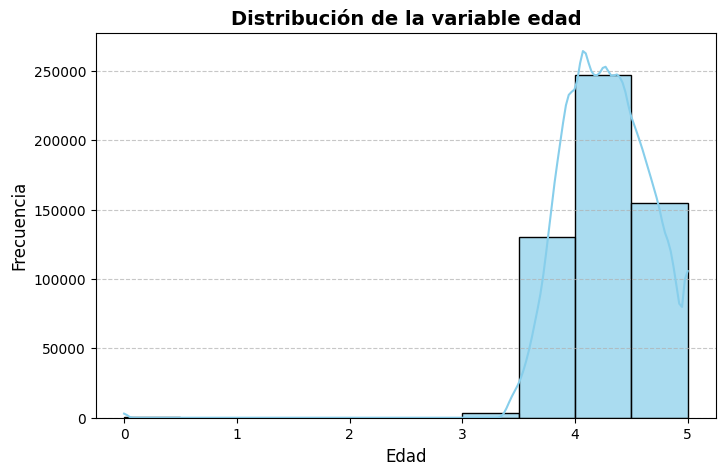

In [81]:
plt.figure(figsize=(8,5)) 
sns.histplot(
    data=df_final,        
    x='edad',         
    bins=10,               
    kde=True,             
    color='skyblue',     
    edgecolor='black',    
    alpha=0.7            
)

plt.title('Distribución de la variable edad', fontsize=14, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.show()


In [82]:
df_final.describe()

,target,edad,ingreso,anios_exp,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,...,ratio_nomina_ingreso,ingreso_otros,total_productos,total_ofertas,ratio_productos_ofertas,solo_ahorro,tiene_credito,cliente_completo,sin_productos,alto_ingreso_sin_productos
count,535943.000000,535943.000000,535943.000000,535943.000000,535943.000000,535943.0,535943.0,535943.0,535943.0,535943.0,...,535943.000000,535943.000000,535943.0,535943.0,535943.0,535943.0,535943.0,535943.0,535943.0,535943.000000
mean,0.259737,4.274235,4.285165,1.326926,1.433891,0.0,0.0,0.0,0.0,0.0,...,0.325919,2.875716,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.249986
std,0.850548,0.378866,0.472804,1.942356,2.020475,0.0,0.0,0.0,0.0,0.0,...,0.458307,1.951202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.433005
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000
25%,0.000000,3.999900,4.105400,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.294550,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000
50%,0.000000,4.265800,4.283400,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,4.064400,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000
75%,0.000000,4.548900,4.503500,3.602900,3.979200,0.0,0.0,0.0,0.0,0.0,...,0.927487,4.333200,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,0.0,0.0,0.0,0.0,0.0,...,1.395557,5.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000


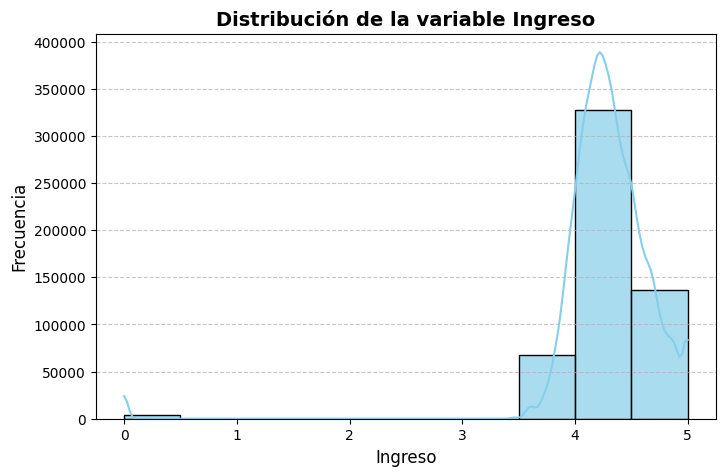

In [83]:
plt.figure(figsize=(8,5)) 
sns.histplot(
    data=df_final,        
    x='ingreso',         
    bins=10,               
    kde=True,             
    color='skyblue',     
    edgecolor='black',    
    alpha=0.7            
)

plt.title('Distribución de la variable Ingreso', fontsize=14, fontweight='bold')
plt.xlabel('Ingreso', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.show()


In [84]:
df_final['ingreso'].describe()

count    535943.000000
mean          4.285165
std           0.472804
min           0.000000
25%           4.105400
50%           4.283400
75%           4.503500
max           5.000000
Name: ingreso, dtype: float64

C:\Users\jlpar\AppData\Local\Temp\ipykernel_2912\1912472721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_final, palette='pastel', edgecolor='black')


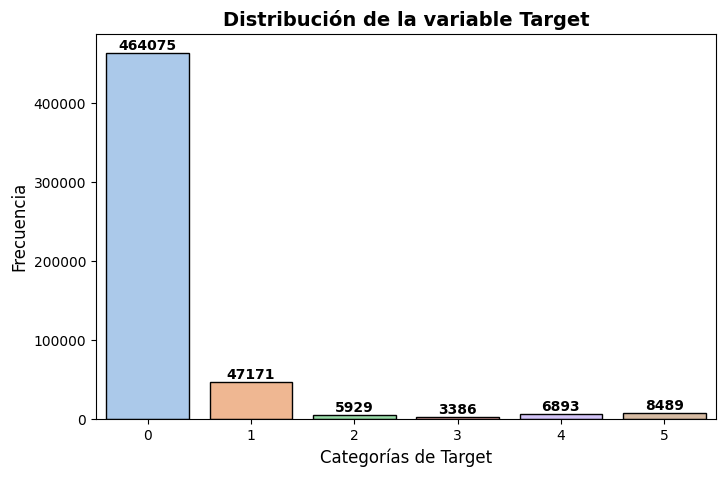

In [85]:
plt.figure(figsize=(8,5))
sns.countplot(x='target', data=df_final, palette='pastel', edgecolor='black')

plt.title('Distribución de la variable Target', fontsize=14, fontweight='bold')
plt.xlabel('Categorías de Target', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Mostrar los valores sobre cada barra
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', label_type='edge', fontsize=10, fontweight='bold')

plt.show()

In [86]:
df_final['tiene_credito'] = df_final['tiene_credito'].astype('category')


In [87]:
df_final['tiene_credito'].describe()

count     535943
unique         1
top            0
freq      535943
Name: tiene_credito, dtype: int64

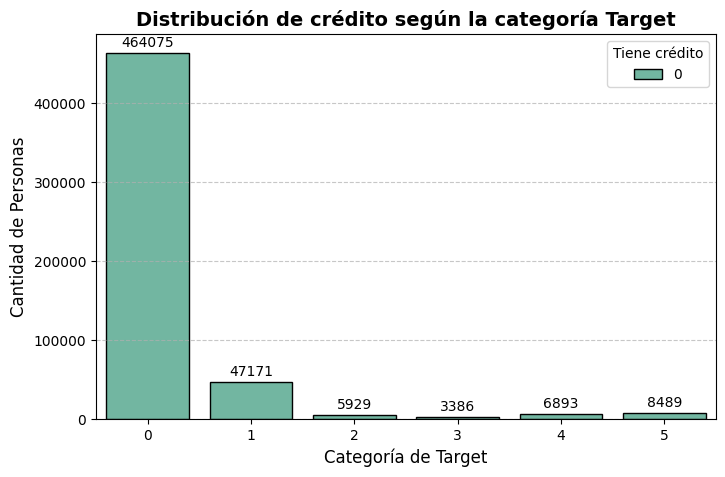

In [88]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df_final,
    x='target',
    hue='tiene_credito',
    palette='Set2',
    edgecolor='black'
)

plt.title('Distribución de crédito según la categoría Target', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Target', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)
plt.legend(title='Tiene crédito')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=2)

plt.show()


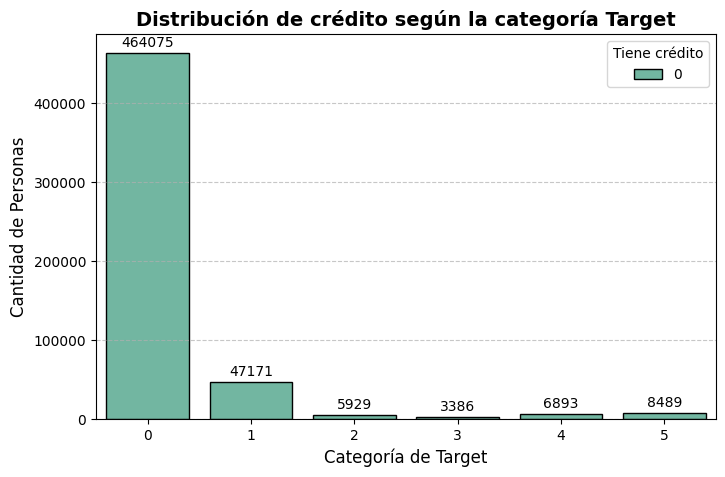

In [89]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df_final,
    x='target',
    hue='tiene_credito',
    palette='Set2',
    edgecolor='black'
)

plt.title('Distribución de crédito según la categoría Target', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Target', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)
plt.legend(title='Tiene crédito')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=2)

plt.show()

In [90]:
df_final['total_ofertas'] = df_final['total_ofertas'].astype('category')


In [91]:
df_final['total_ofertas'].value_counts()

total_ofertas
0.0    535943
Name: count, dtype: int64

In [92]:
df_final['cuenta_ahorro'].value_counts()

cuenta_ahorro
0.0    535943
Name: count, dtype: int64

In [93]:
df_final.to_csv("df_final.csv", index=False)

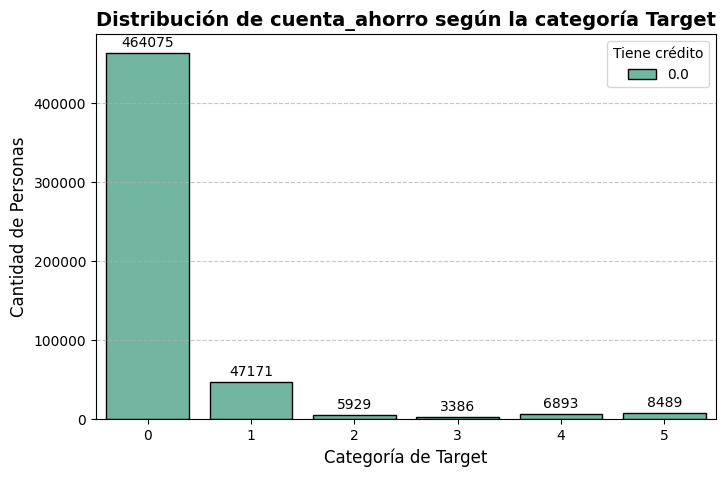

In [94]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df_final,
    x='target',
    hue='cuenta_ahorro',
    palette='Set2',
    edgecolor='black'
)

plt.title('Distribución de cuenta_ahorro según la categoría Target', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Target', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)
plt.legend(title='Tiene crédito')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=2)

plt.show()

C:\Users\jlpar\AppData\Local\Temp\ipykernel_25524\2565224567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='target', y='ingreso', ax=axes[0], palette='coolwarm')
C:\Users\jlpar\AppData\Local\Temp\ipykernel_25524\2565224567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='target', y='anios_exp', ax=axes[1], palette='coolwarm')


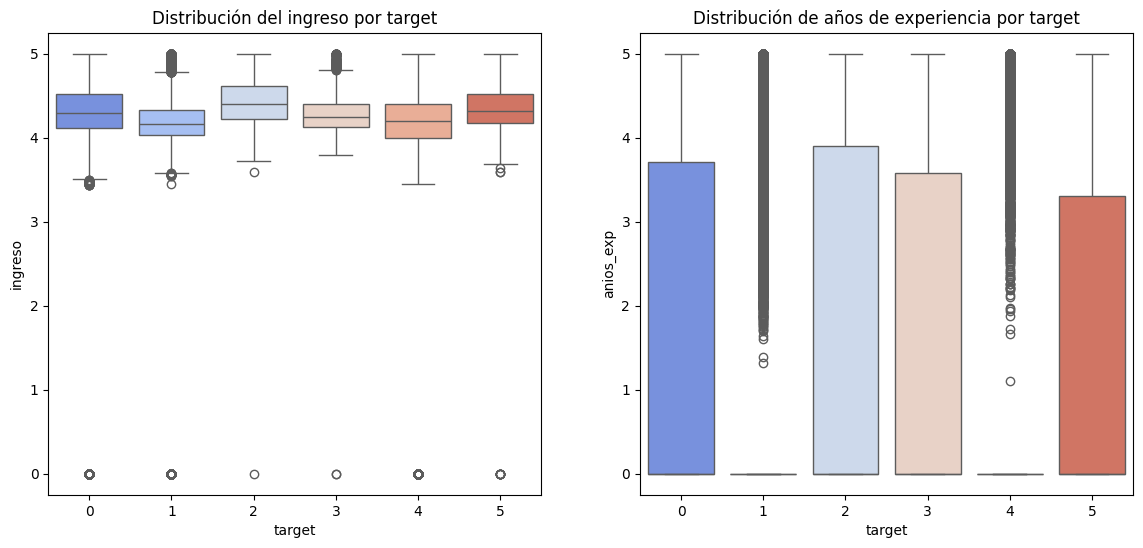

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.boxplot(data=df_final, x='target', y='ingreso', ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribución del ingreso por target')

sns.boxplot(data=df_final, x='target', y='anios_exp', ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribución de años de experiencia por target')

plt.show()

C:\Users\jlpar\AppData\Local\Temp\ipykernel_25524\2924422082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='target', y=r, palette='viridis')


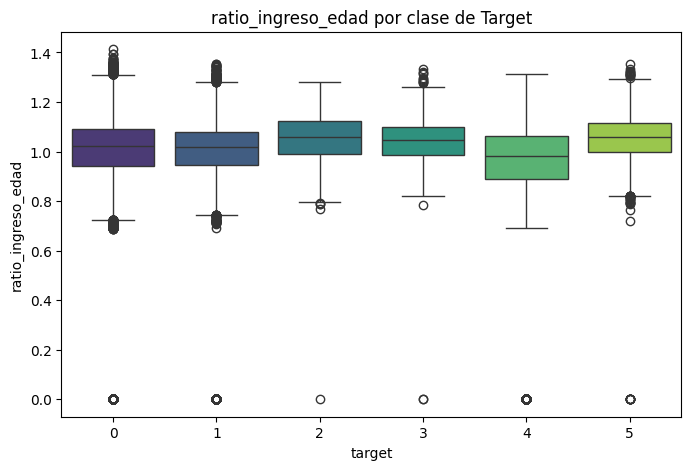

C:\Users\jlpar\AppData\Local\Temp\ipykernel_25524\2924422082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='target', y=r, palette='viridis')


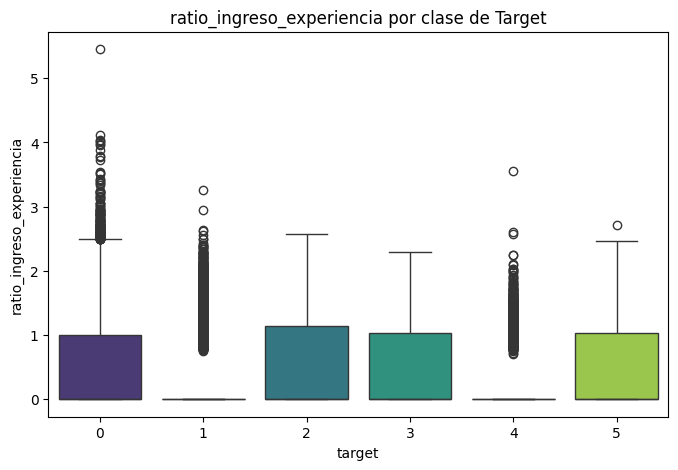

C:\Users\jlpar\AppData\Local\Temp\ipykernel_25524\2924422082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='target', y=r, palette='viridis')


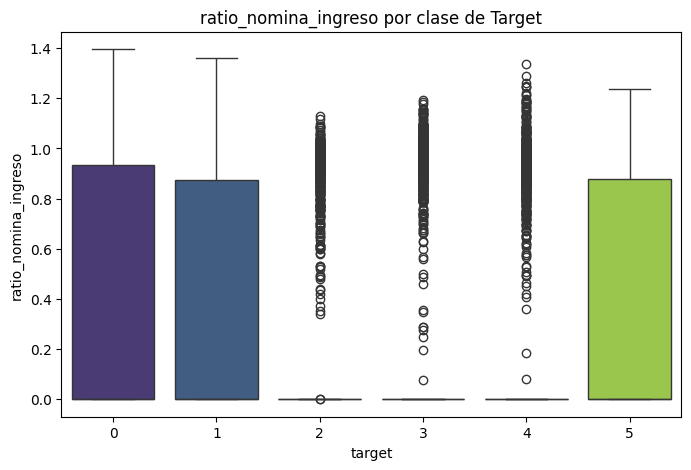

In [193]:
ratios = ['ratio_ingreso_edad', 'ratio_ingreso_experiencia', 'ratio_nomina_ingreso']

for r in ratios:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_final, x='target', y=r, palette='viridis')
    plt.title(f'{r} por clase de Target')
    plt.show()


In [1]:
sns.boxplot(x='target', y='ingreso', data=df_final)
plt.yscale('log')
plt.title('Distribución del Ingreso por Target (Escala Logarítmica)')
plt.show()

NameError: name 'sns' is not defined

C:\Users\jlpar\AppData\Local\Temp\ipykernel_25524\2376948304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='target', y='total_productos', ax=axes[0], palette='mako')
C:\Users\jlpar\AppData\Local\Temp\ipykernel_25524\2376948304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='target', y='total_ofertas', ax=axes[1], palette='mako')


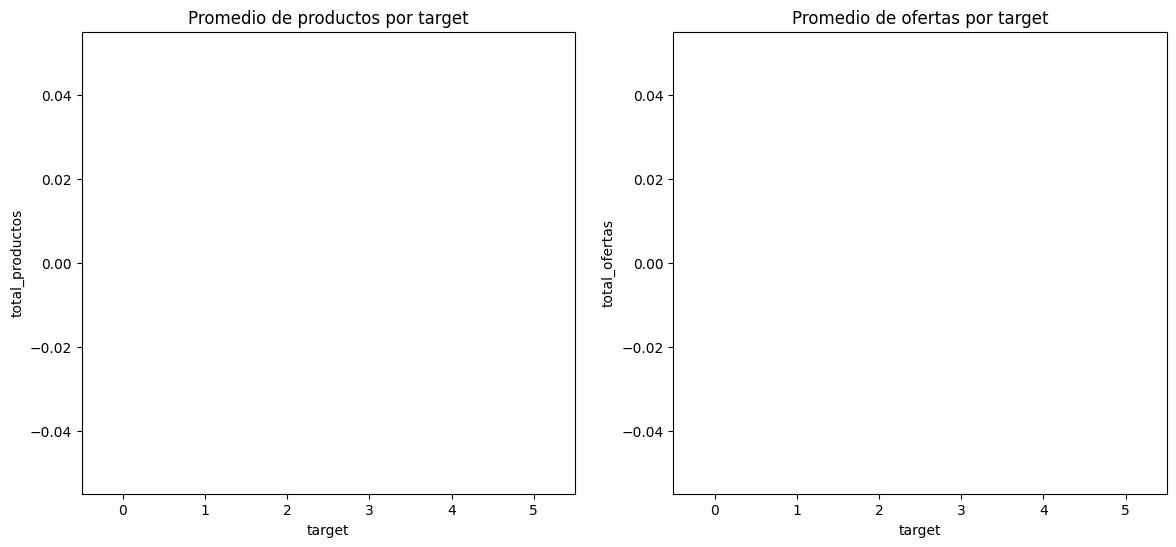

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(data=df_final, x='target', y='total_productos', ax=axes[0], palette='mako')
axes[0].set_title('Promedio de productos por target')

sns.barplot(data=df_final, x='target', y='total_ofertas', ax=axes[1], palette='mako')
axes[1].set_title('Promedio de ofertas por target')

plt.show()

Columnas a visualizar: ['edad', 'ingreso', 'anios_exp', 'pago_nomina']
Número de columnas a visualizar: 4
Número de axes creados: 8


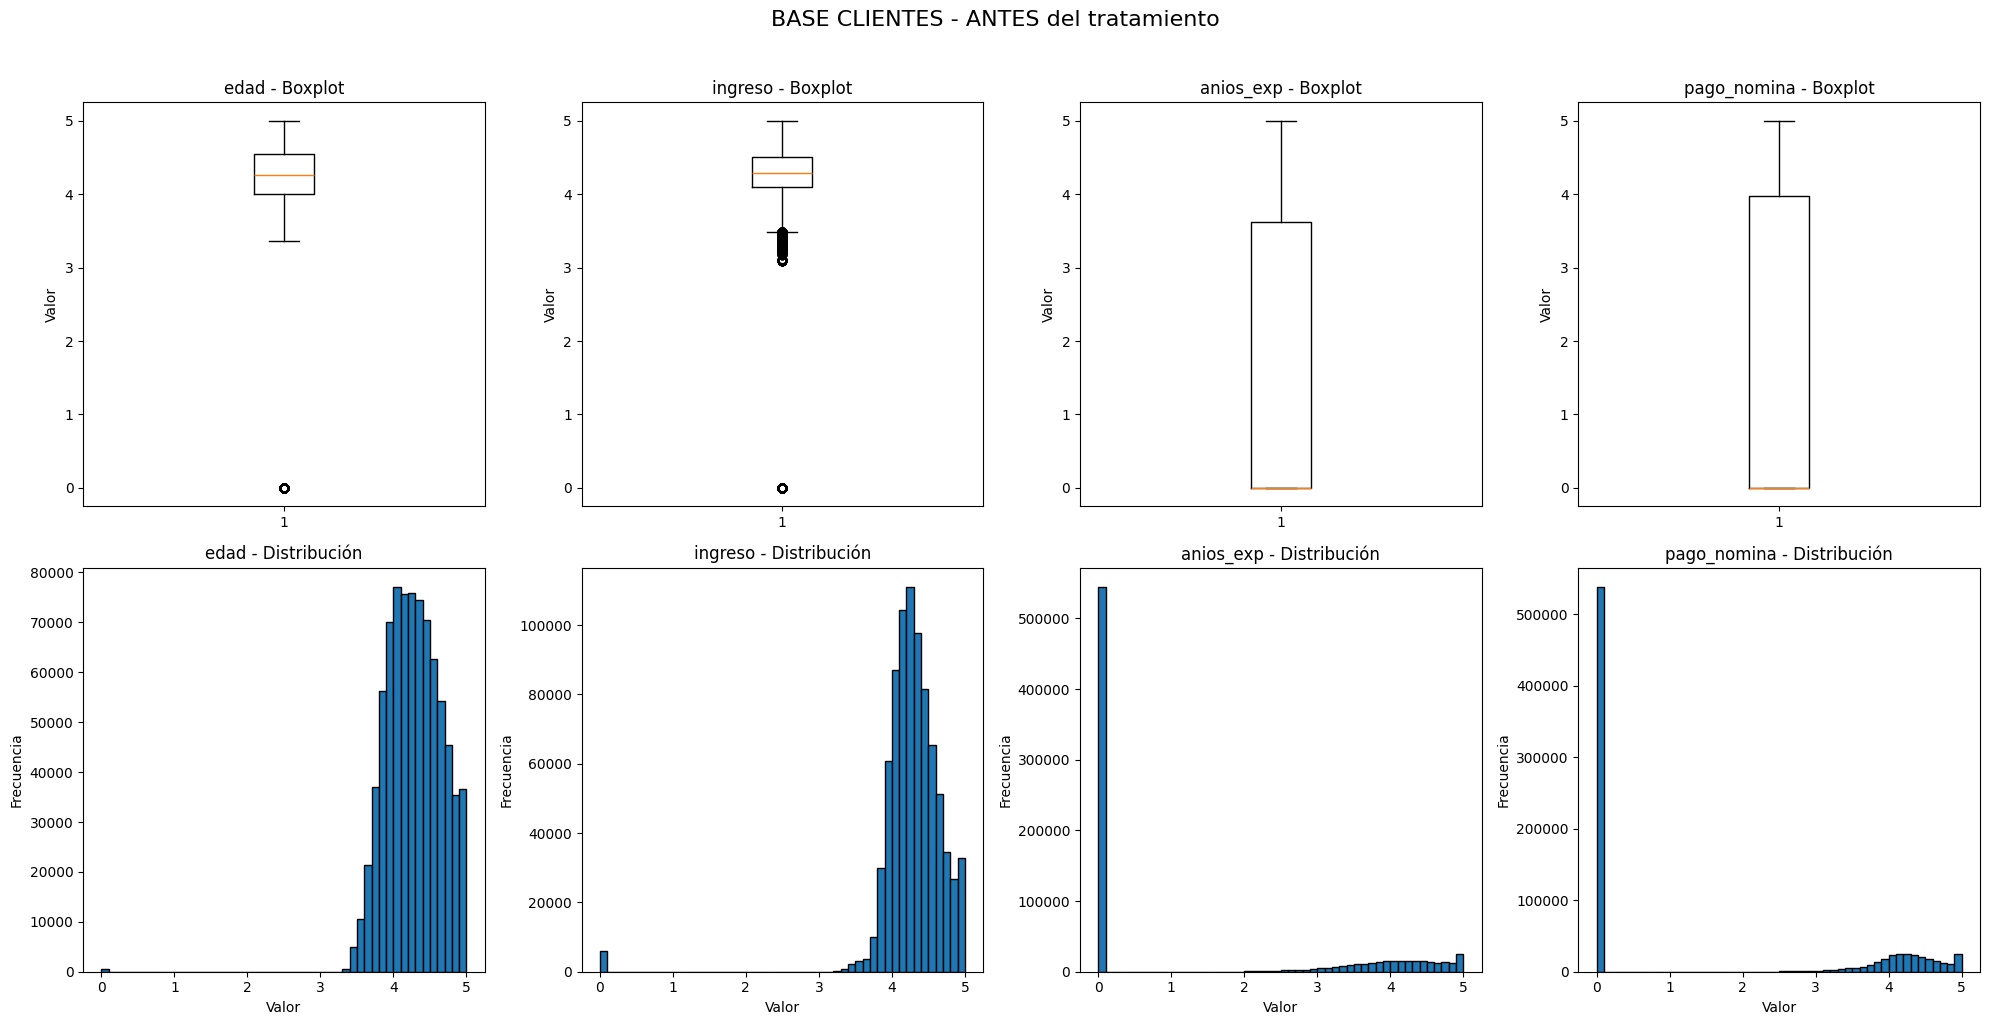


📊 edad:
  - Rango normal: [3.18, 5.37]
  - Outliers detectados: 576 (0.07%)

📊 ingreso:
  - Rango normal: [3.48, 5.13]
  - Outliers detectados: 8884 (1.10%)

📊 anios_exp:
  - Rango normal: [-5.43, 9.05]
  - Outliers detectados: 0 (0.00%)

📊 pago_nomina:
  - Rango normal: [-5.96, 9.93]
  - Outliers detectados: 0 (0.00%)


In [ ]:
# 4.1 DETECCIÓN DE OUTLIERS (método IQR)
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lower_bound) | (df[columna] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Visualizar outliers antes del tratamiento
def visualizar_outliers(df, columnas, titulo):
    print(f"Columnas a visualizar: {columnas}")
    print(f"Número de columnas a visualizar: {len(columnas)}")
    fig, axes = plt.subplots(2, len(columnas), figsize=(5*len(columnas), 10))
    print(f"Número de axes creados: {axes.size if isinstance(axes, np.ndarray) else 1}")


    for i, col in enumerate(columnas):
        # Boxplot
        axes[0, i].boxplot(df[col].dropna())
        axes[0, i].set_title(f'{col} - Boxplot')
        axes[0, i].set_ylabel('Valor')

        # Histograma
        axes[1, i].hist(df[col].dropna(), bins=50, edgecolor='black')
        axes[1, i].set_title(f'{col} - Distribución')
        axes[1, i].set_xlabel('Valor')
        axes[1, i].set_ylabel('Frecuencia')

    plt.suptitle(f'{titulo} - ANTES del tratamiento', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Analizar outliers en base_clientes
visualizar_outliers(base_clientes, bcnum, "BASE CLIENTES")

# Reportar outliers
for col in bcnum:
    outliers, lower, upper = detectar_outliers_iqr(base_clientes, col)
    print(f"\n📊 {col}:")
    print(f"  - Rango normal: [{lower:.2f}, {upper:.2f}]")
    print(f"  - Outliers detectados: {len(outliers)} ({len(outliers)/len(base_clientes)*100:.2f}%)")

In [ ]:
# 4.2 TRATAMIENTO: WINSORIZATION (clip a percentiles)
from scipy.stats import mstats
base_clientes_clean_outliers = base_clientes.copy()

for col in bc_numericas:
    # Clip a percentiles 1 y 99
    p01 = base_clientes_clean_outliers[col].quantile(0.01)
    p99 = base_clientes_clean_outliers[col].quantile(0.99)

    antes = base_clientes_clean_outliers[col].copy()
    base_clientes_clean_outliers[col] = base_clientes_clean_outliers[col].clip(p01, p99)

    modificados = (antes != base_clientes_clean_outliers[col]).sum()
    print(f"✅ {col}: {modificados} valores ajustados (clip a P01={p01:.2f}, P99={p99:.2f})")

✅ edad: 8090 valores ajustados (clip a P01=3.53, P99=5.00)
✅ ingreso: 8095 valores ajustados (clip a P01=3.46, P99=5.00)
✅ anios_exp: 0 valores ajustados (clip a P01=0.00, P99=5.00)
✅ pago_nomina: 0 valores ajustados (clip a P01=0.00, P99=5.00)


Columnas a visualizar: ['edad', 'ingreso', 'anios_exp', 'pago_nomina']
Número de columnas a visualizar: 4
Número de axes creados: 8


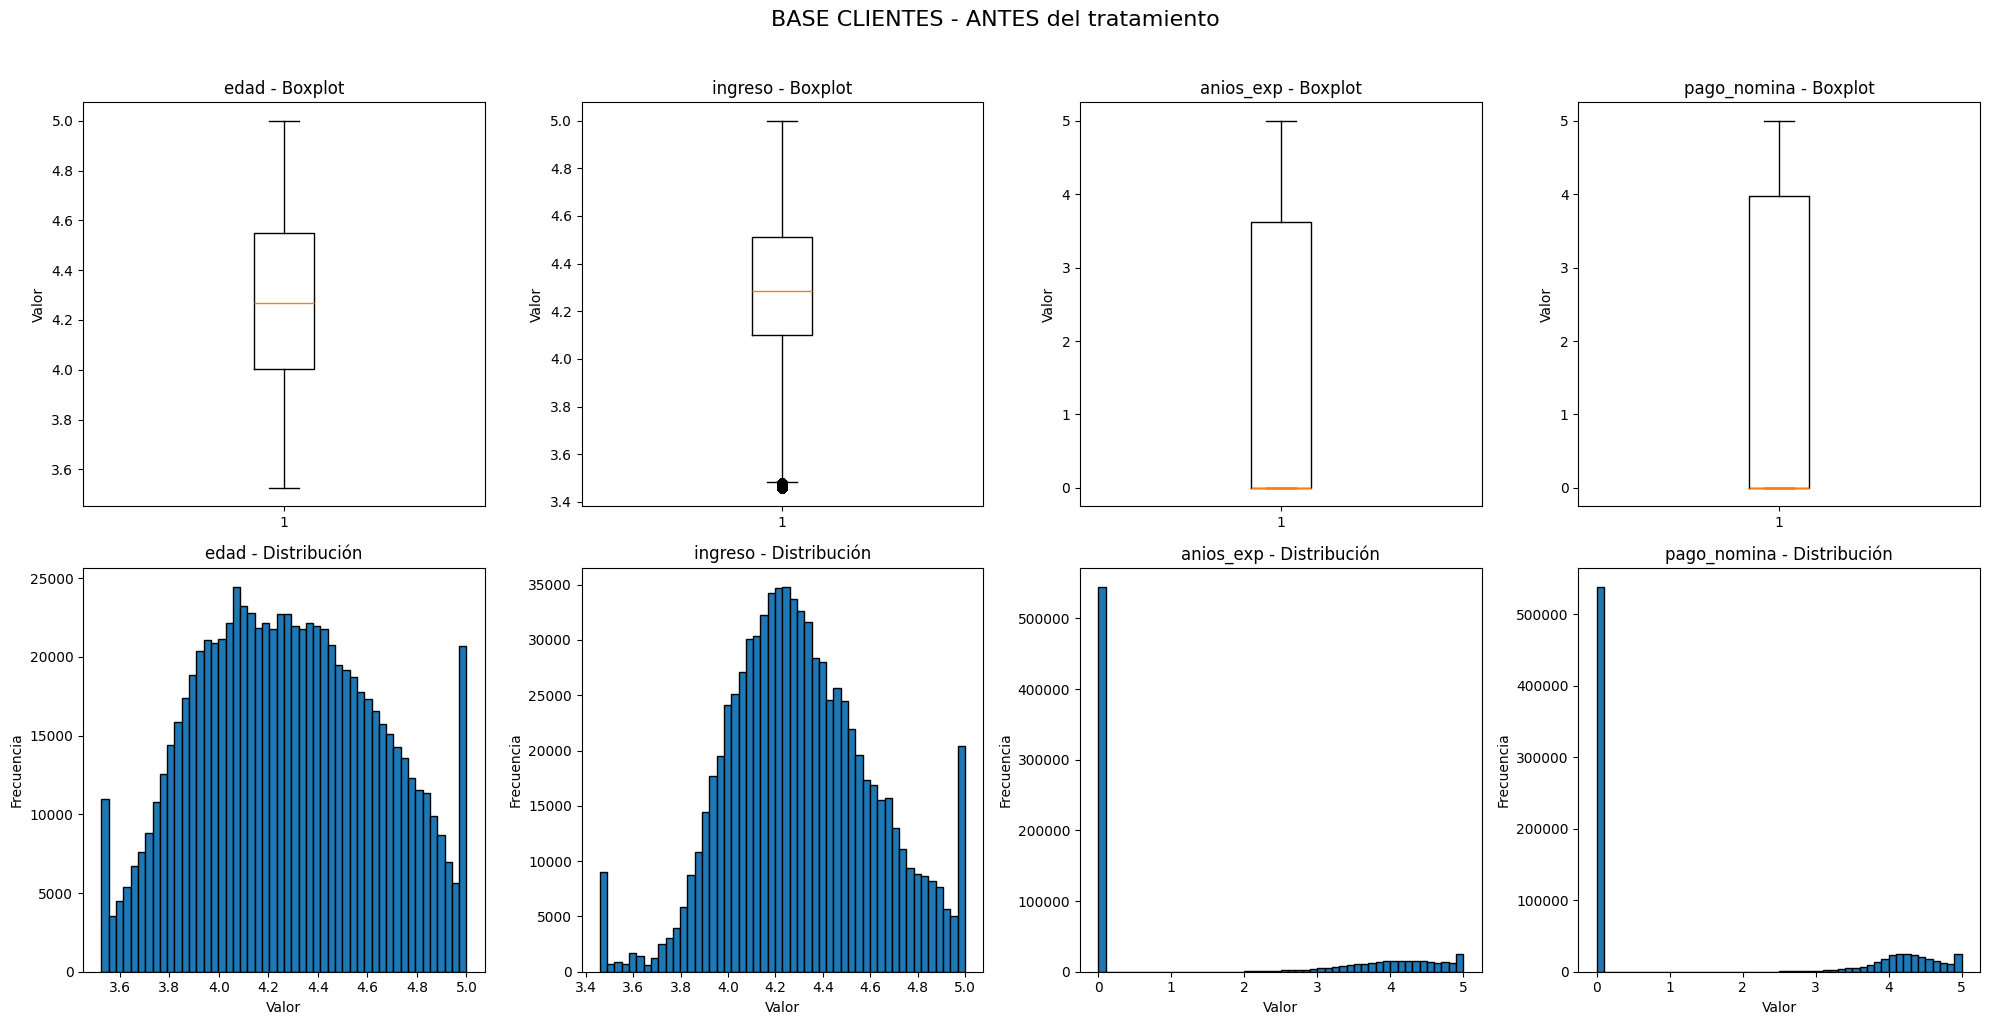

In [ ]:
# Visualizar después
visualizar_outliers(base_clientes_clean_outliers, bcnum, "BASE CLIENTES")


#**REVISION VARIABLES CATEGORICAS**

In [ ]:


bccat = ['tipo_empleo','buro_de_credito','tc','prest_per','prest_veh_hip','cuenta_ahorro','ofer_prest_per','ofer_tc','ofer_compra_deuda']
base_clientes_clean_outliers_categoricas = base_clientes_clean_outliers[bccat]

In [ ]:
base_clientes_clean_outliers.describe(include=['object'])

,ID,tipo_empleo,buro_de_credito,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
count,809579,809579,809579,809579,809579,809579,809579,809579,809579,809579
unique,809579,7,9,2,2,2,2,2,2,2
top,ccb883a647ce35beb68e0dd8518643acca047564ba9464...,type_2,category_9,No,No,No,Yes,No,No,No
freq,1,427979,185255,551066,748643,787905,793292,691652,669530,771301


In [ ]:
# ============================================
# ANÁLISIS DE VARIABLES CATEGÓRICAS
# ============================================




print("🏷️ ANÁLISIS DETALLADO DE VARIABLES CATEGÓRICAS")

# Función para analizar cada categórica
def analizar_categorica(df, columna):
    print(f"\n{'─'*70}")
    print(f"📊 VARIABLE: {columna.upper()}")
    print(f"{'─'*70}")

    # Valores únicos
    n_unicos = df[columna].nunique()
    print(f"✓ Valores únicos: {n_unicos}")

    # Frecuencias
    freq = df[columna].value_counts()
    freq_pct = df[columna].value_counts(normalize=True) * 100

    resumen = pd.DataFrame({
        'Frecuencia': freq,
        'Porcentaje': freq_pct.round(2)
    })
    print(f"\n{resumen}")

    # Identificar problemas
    problemas = []

    # 1. Categorías raras (< 1%)
    raras = freq_pct[freq_pct < 1]
    if len(raras) > 0:
        problemas.append(f"⚠️ {len(raras)} categorías con < 1%: {list(raras.index)}")

    # 2. Categorías dominantes (> 90%)
    dominante = freq_pct[freq_pct > 90]
    if len(dominante) > 0:
        problemas.append(f"⚠️ Categoría dominante (>{dominante.values[0]:.1f}%): {dominante.index[0]}")

    # 3. Alta cardinalidad (> 10 categorías)
    if n_unicos > 10:
        problemas.append(f"⚠️ Alta cardinalidad ({n_unicos} categorías)")

    # 4. Valores nulos
    n_nulos = df[columna].isnull().sum()
    pct_nulos = (n_nulos / len(df)) * 100
    if n_nulos > 0:
        problemas.append(f"⚠️ {n_nulos} valores nulos ({pct_nulos:.2f}%)")

    # Mostrar problemas
    if problemas:
        print(f"\n🔍 PROBLEMAS DETECTADOS:")
        for problema in problemas:
            print(f"   {problema}")
    else:
        print(f"\n✅ No se detectaron problemas")

    return {
        'columna': columna,
        'n_unicos': n_unicos,
        'n_nulos': n_nulos,
        'pct_nulos': pct_nulos,
        'tiene_raras': len(raras) > 0,
        'tiene_dominante': len(dominante) > 0,
        'alta_cardinalidad': n_unicos > 10
    }

# Analizar todas las categóricas
resultados = []
for col in bccat:
    resultado = analizar_categorica(base_clientes_clean_outliers_categoricas, col)
    resultados.append(resultado)


🏷️ ANÁLISIS DETALLADO DE VARIABLES CATEGÓRICAS

──────────────────────────────────────────────────────────────────────
📊 VARIABLE: TIPO_EMPLEO
──────────────────────────────────────────────────────────────────────
✓ Valores únicos: 7

             Frecuencia  Porcentaje
tipo_empleo                        
type_2           427979       52.86
type_7           245397       30.31
type_3            52275        6.46
type_1            39675        4.90
type_4            22196        2.74
type_5            20520        2.53
type_6             1537        0.19

🔍 PROBLEMAS DETECTADOS:
   ⚠️ 1 categorías con < 1%: ['type_6']

──────────────────────────────────────────────────────────────────────
📊 VARIABLE: BURO_DE_CREDITO
──────────────────────────────────────────────────────────────────────
✓ Valores únicos: 9

                 Frecuencia  Porcentaje
buro_de_credito                        
category_9           185255       22.88
category_2           118766       14.67
category_4           116


 VARIABLES CON BAJA VARIABILIDAD

prest_veh_hip: "No" representa el 97.3%

cuenta_ahorro: "Yes" representa el 98.0%

ofer_compra_deuda: "No" representa el 95.3%


Conclusión: Estas variables tienen poca capacidad predictiva. Considerar eliminarlas después de ver su correlación con el target.

In [ ]:
base_clientes_clean_outliers_binarias = ['tc', 'prest_per', 'prest_veh_hip',
             'cuenta_ahorro', 'ofer_prest_per', 'ofer_tc', 'ofer_compra_deuda']

base_clientes_clean_outliers_multivaluadas = ['tipo_empleo', 'buro_de_credito']

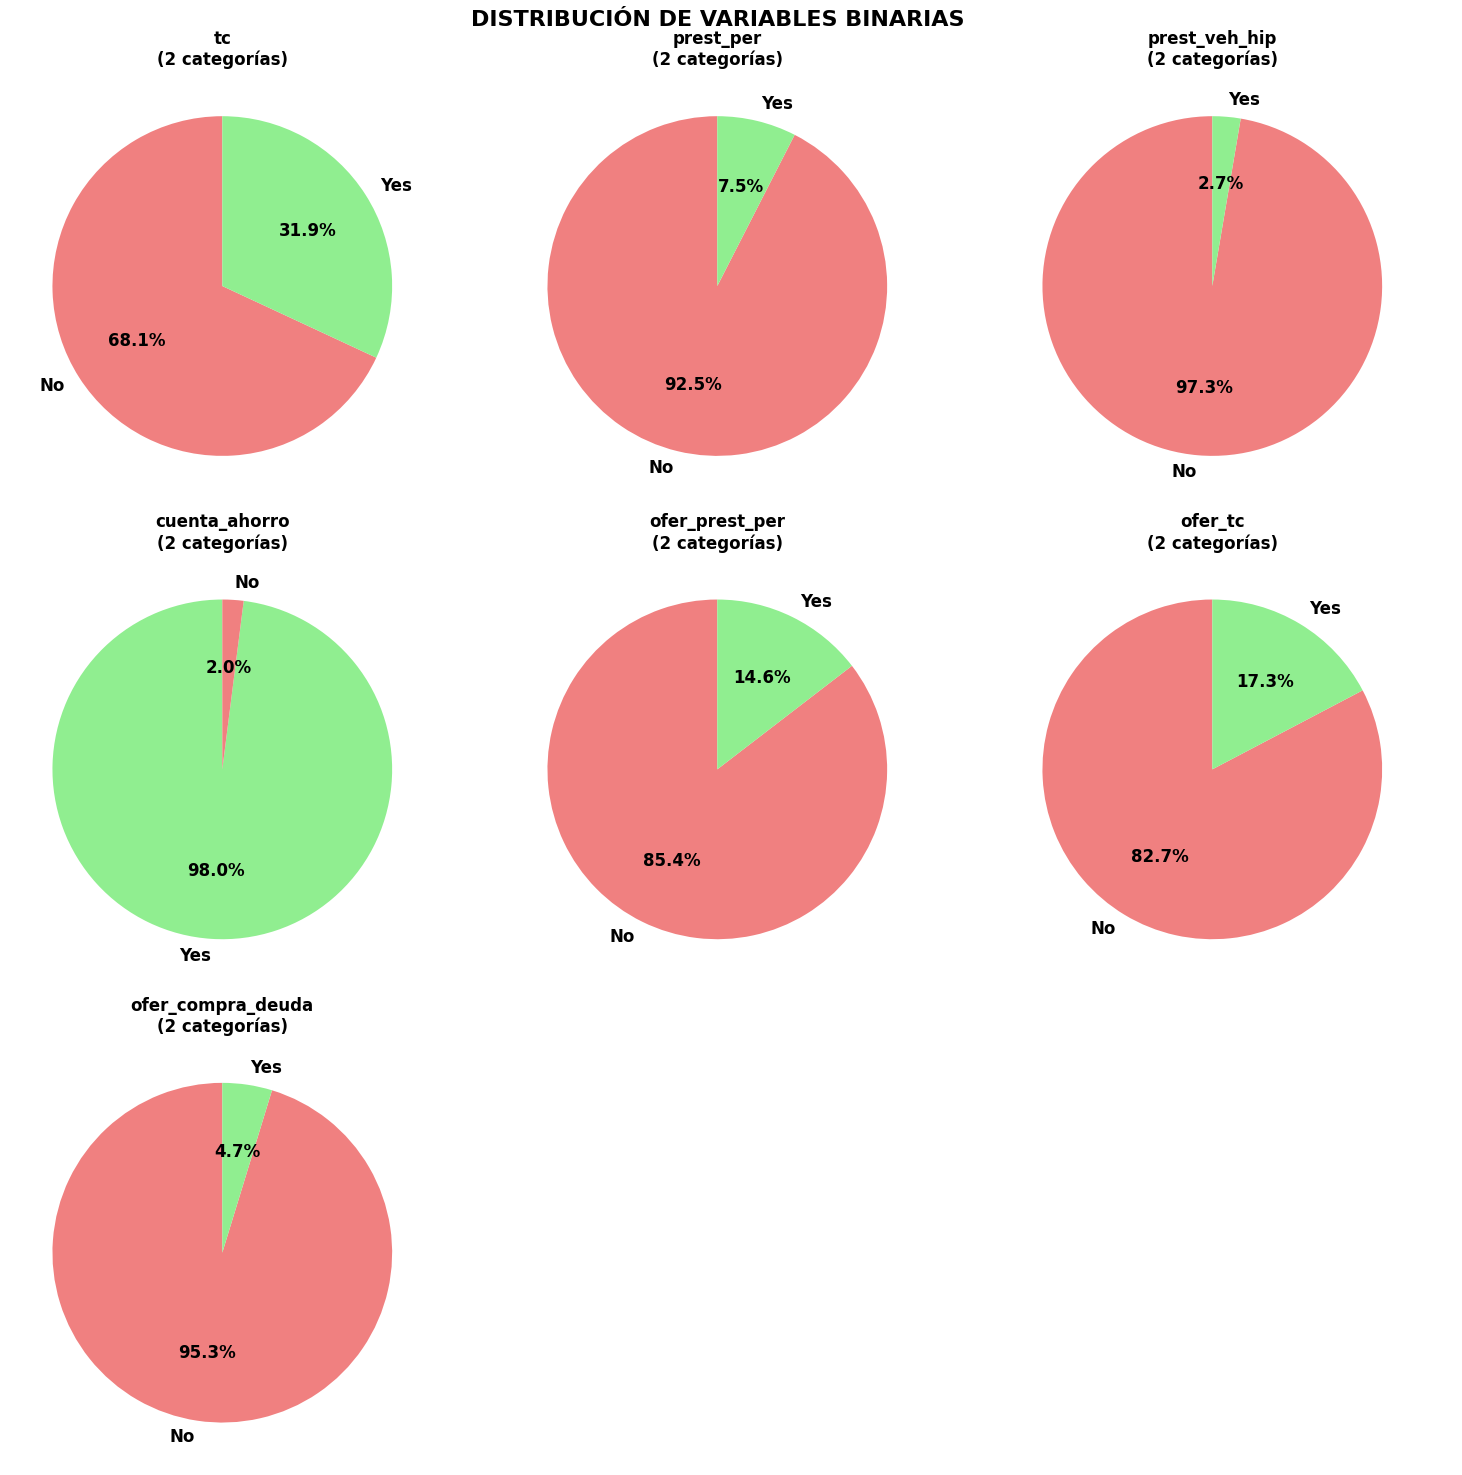

In [ ]:
#Graficando variables binarias
if len(base_clientes_clean_outliers_binarias) > 0:
    n_bin = len(base_clientes_clean_outliers_binarias)
    n_cols = 3
    n_rows = (n_bin + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_bin > 1 else [axes]

    for i, col in enumerate(base_clientes_clean_outliers_binarias):
        freq = base_clientes[col].value_counts()
        colors = ['lightgreen', 'lightcoral'] if freq.index[0] in ['Yes', 'Sí', 1] else ['lightcoral', 'lightgreen']

        axes[i].pie(freq.values, labels=freq.index, autopct='%1.1f%%',
                    startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
        axes[i].set_title(f'{col}\n({base_clientes[col].nunique()} categorías)',
                         fontsize=12, fontweight='bold')

    # Ocultar ejes sobrantes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('DISTRIBUCIÓN DE VARIABLES BINARIAS', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


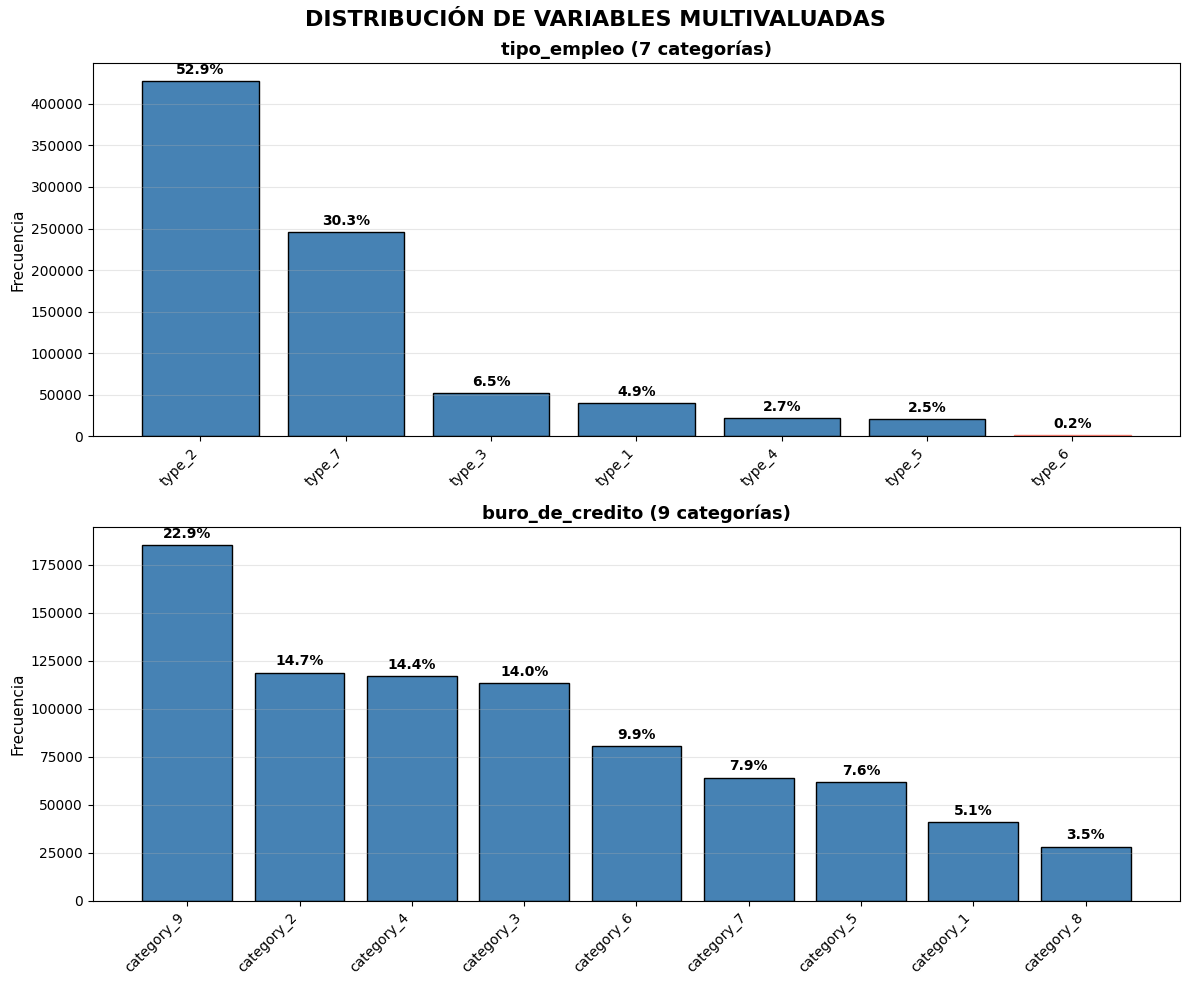

In [ ]:

#Graficando variables multivaluadas
if len(base_clientes_clean_outliers_multivaluadas) > 0:
    n_multi = len(base_clientes_clean_outliers_multivaluadas)
    fig, axes = plt.subplots(n_multi, 1, figsize=(12, 5*n_multi))
    axes = axes if n_multi > 1 else [axes]

    for i, col in enumerate(base_clientes_clean_outliers_multivaluadas):
        freq = base_clientes[col].value_counts()

        # Barplot
        axes[i].bar(range(len(freq)), freq.values, color='steelblue', edgecolor='black')
        axes[i].set_xticks(range(len(freq)))
        axes[i].set_xticklabels(freq.index, rotation=45, ha='right')
        axes[i].set_title(f'{col} ({len(freq)} categorías)', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('Frecuencia', fontsize=11)
        axes[i].grid(alpha=0.3, axis='y')

        # Anotar porcentajes
        for j, (cat, count) in enumerate(freq.items()):
            pct = (count / len(base_clientes)) * 100
            axes[i].text(j, count + max(freq)*0.02, f'{pct:.1f}%',
                        ha='center', fontsize=10, fontweight='bold')

        # Resaltar categorías raras (< 1%)
        freq_pct = freq / len(base_clientes) * 100
        raras_idx = [j for j, pct in enumerate(freq_pct) if pct < 1]
        if raras_idx:
            for idx in raras_idx:
                axes[i].get_children()[idx].set_color('salmon')

    plt.suptitle('DISTRIBUCIÓN DE VARIABLES MULTIVALUADAS', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
base_clientes_clean_outliers.head()

,ID,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No


#**Se procede a realizar codificación de variables**

Se procederá a utilizar One hot encoding ya que es una técnica más robusta para los diferentes modelos que se pueden utilizar



In [ ]:
# ============================================
# CODIFICACIÓN DE VARIABLES - BASE_CLIENTES
# ============================================

print("="*70)
print("🔢 INICIANDO CODIFICACIÓN DE VARIABLES")
print("="*70)

# Crear copia para no modificar el original
base_clientes_encoded = base_clientes_clean_outliers.copy()

print(f"\n📊 Dataset original: {base_clientes_clean_outliers.shape}")

# ─────────────────────────────────────────────────────────────
# PASO 1: CODIFICAR VARIABLES BINARIAS (Label Encoding)
# ─────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("1️⃣ CODIFICANDO VARIABLES BINARIAS (Yes/No → 1/0)")
print("─"*70)



for col in base_clientes_clean_outliers_binarias:
    # Verificar valores antes
    valores_antes = base_clientes_encoded[col].unique()

    # Convertir Yes=1, No=0
    base_clientes_encoded[col] = (base_clientes_encoded[col] == 'Yes').astype(int)

    # Mostrar resultado
    print(f"\n✅ {col}:")
    print(f"   Valores antes: {valores_antes}")
    print(f"   Valores después: {base_clientes_encoded[col].unique()}")
    print(f"   Distribución: 0={base_clientes_encoded[col].value_counts().get(0, 0)}, "
          f"1={base_clientes_encoded[col].value_counts().get(1, 0)}")

# ─────────────────────────────────────────────────────────────
# PASO 2: ONE-HOT ENCODING PARA TIPO_EMPLEO
# ─────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("2️⃣ CODIFICANDO TIPO_EMPLEO (One-Hot Encoding)")
print("─"*70)

print(f"\n📌 tipo_empleo:")
print(f"   Categorías antes: {base_clientes_encoded['tipo_empleo'].nunique()}")
print(f"   Valores: {base_clientes_encoded['tipo_empleo'].unique()}")
print(f"\n   Distribución:")
print(base_clientes_encoded['tipo_empleo'].value_counts())

# Aplicar One-Hot Encoding
base_clientes_encoded = pd.get_dummies(
    base_clientes_encoded,
    columns=['tipo_empleo'],
    prefix='empleo',
    drop_first=True,  # Elimina una categoría de referencia
    dtype=int
)

# Mostrar columnas creadas
columnas_empleo = [col for col in base_clientes_encoded.columns if 'empleo_' in col]
print(f"\n✅ One-Hot Encoding aplicado")
print(f"   Columnas creadas: {len(columnas_empleo)}")
print(f"   Nombres:")
for col in columnas_empleo:
    count_ones = base_clientes_encoded[col].sum()
    print(f"      • {col}: {count_ones} registros con valor 1")

# ─────────────────────────────────────────────────────────────
# PASO 3: ONE-HOT ENCODING PARA BURO_DE_CREDITO
# ─────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("3️⃣ CODIFICANDO BURO_DE_CREDITO (One-Hot Encoding)")
print("─"*70)

print(f"\n📌 buro_de_credito:")
print(f"   Categorías antes: {base_clientes_encoded['buro_de_credito'].nunique()}")
print(f"   Valores: {base_clientes_encoded['buro_de_credito'].unique()}")
print(f"\n   Distribución:")
print(base_clientes_encoded['buro_de_credito'].value_counts().sort_index())

# Aplicar One-Hot Encoding
base_clientes_encoded = pd.get_dummies(
    base_clientes_encoded,
    columns=['buro_de_credito'],
    prefix='buro',
    drop_first=True,  # Elimina una categoría de referencia
    dtype=int
)

# Mostrar columnas creadas
columnas_buro = [col for col in base_clientes_encoded.columns if 'buro_' in col]
print(f"\n✅ One-Hot Encoding aplicado")
print(f"   Columnas creadas: {len(columnas_buro)}")
print(f"   Nombres:")
for col in columnas_buro:
    count_ones = base_clientes_encoded[col].sum()
    print(f"      • {col}: {count_ones} registros con valor 1")

# ─────────────────────────────────────────────────────────────
# VERIFICACIÓN FINAL
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("✅ CODIFICACIÓN COMPLETADA")
print("="*70)

# Dimensiones
print(f"\n📏 Dimensiones:")
print(f"   Antes:  {base_clientes_clean_outliers.shape}")
print(f"   Después: {base_clientes_encoded.shape}")
print(f"   Columnas añadidas: {base_clientes_encoded.shape[1] - base_clientes_clean_outliers.shape[1]}")

# Tipos de datos
print(f"\n📋 Tipos de datos:")
print(base_clientes_encoded.dtypes.value_counts())

# Variables categóricas restantes (tipo object)
categoricas_restantes = base_clientes_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"\n🔍 Variables tipo 'object' restantes: {categoricas_restantes}")
if len(categoricas_restantes) <= 1:  # Solo debería quedar ID
    print("   ✅ Correcto (solo ID debería ser tipo object)")
else:
    print("   ⚠️ Atención: Hay más variables categóricas sin codificar")

# Valores nulos
nulos_totales = base_clientes_encoded.isnull().sum().sum()
print(f"\n❓ Valores nulos totales: {nulos_totales}")
if nulos_totales > 0:
    print("   ⚠️ Hay valores nulos:")
    print(base_clientes_encoded.isnull().sum()[base_clientes_encoded.isnull().sum() > 0])
else:
    print("   ✅ No hay valores nulos")

# Resumen de columnas creadas
print(f"\n📊 RESUMEN DE COLUMNAS NUEVAS:")
print(f"   Variables binarias codificadas: {len(base_clientes_clean_outliers_binarias)} (sin cambio dimensional)")
print(f"   tipo_empleo → {len(columnas_empleo)} columnas")
print(f"   buro_de_credito → {len(columnas_buro)} columnas")
print(f"   Total columnas nuevas: {len(columnas_empleo) + len(columnas_buro)}")

# Mostrar primeras filas
print(f"\n👀 PRIMERAS 3 FILAS DEL DATASET CODIFICADO:")
print(base_clientes_encoded.head(3))

print("\n" + "="*70)
print("🎯 Dataset listo para merge con otras tablas")
print("="*70)

🔢 INICIANDO CODIFICACIÓN DE VARIABLES

📊 Dataset original: (809579, 14)

──────────────────────────────────────────────────────────────────────
1️⃣ CODIFICANDO VARIABLES BINARIAS (Yes/No → 1/0)
──────────────────────────────────────────────────────────────────────

✅ tc:
   Valores antes: ['Yes' 'No']
   Valores después: [1 0]
   Distribución: 0=551066, 1=258513

✅ prest_per:
   Valores antes: ['No' 'Yes']
   Valores después: [0 1]
   Distribución: 0=748643, 1=60936

✅ prest_veh_hip:
   Valores antes: ['No' 'Yes']
   Valores después: [0 1]
   Distribución: 0=787905, 1=21674

✅ cuenta_ahorro:
   Valores antes: ['Yes' 'No']
   Valores después: [1 0]
   Distribución: 0=16287, 1=793292

✅ ofer_prest_per:
   Valores antes: ['No' 'Yes']
   Valores después: [0 1]
   Distribución: 0=691652, 1=117927

✅ ofer_tc:
   Valores antes: ['No' 'Yes']
   Valores después: [0 1]
   Distribución: 0=669530, 1=140049

✅ ofer_compra_deuda:
   Valores antes: ['No' 'Yes']
   Valores después: [0 1]
   Distribuci

In [ ]:
base_clientes_encoded.head()

,ID,edad,ingreso,anios_exp,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,...,empleo_type_6,empleo_type_7,buro_category_2,buro_category_3,buro_category_4,buro_category_5,buro_category_6,buro_category_7,buro_category_8,buro_category_9
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,4.8095,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,0.0000,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,0.0000,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,0.0000,1,1,1,1,0,...,0,1,0,1,0,0,0,0,0,0
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,0.0000,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0


In [ ]:
base_clientes_encoded.columns.tolist()

['ID',
 'edad',
 'ingreso',
 'anios_exp',
 'pago_nomina',
 'tc',
 'prest_per',
 'prest_veh_hip',
 'cuenta_ahorro',
 'ofer_prest_per',
 'ofer_tc',
 'ofer_compra_deuda',
 'empleo_type_2',
 'empleo_type_3',
 'empleo_type_4',
 'empleo_type_5',
 'empleo_type_6',
 'empleo_type_7',
 'buro_category_2',
 'buro_category_3',
 'buro_category_4',
 'buro_category_5',
 'buro_category_6',
 'buro_category_7',
 'buro_category_8',
 'buro_category_9']

#**Creación de nuevas variables**


In [ ]:
#Ratios de relaciones financieras

base_clientes_fe = base_clientes_encoded.copy()
base_clientes_fe['ratio_ingreso_edad'] = base_clientes_fe['ingreso'] / (base_clientes_fe['edad'] + 1)
#ratio_ingreso_edad: Ingreso entre edad (productividad)

base_clientes_fe['ratio_ingreso_experiencia'] = base_clientes_fe['ingreso'] / (base_clientes_fe['anios_exp'] + 1)
#ratio_ingreso_experiencia: Ingreso entre años de experiencia

base_clientes_fe['ratio_nomina_ingreso'] = base_clientes_fe['pago_nomina'] / (base_clientes_fe['ingreso'] + 0.01)
#ratio_nomina_ingreso: Qué % del ingreso viene de nómina



In [ ]:
base_clientes_fe['ingreso_otros'] = base_clientes_fe['ingreso'] - base_clientes_fe['pago_nomina']
base_clientes_fe['ingreso_otros'] = base_clientes_fe['ingreso_otros'].clip(lower=0)  # No negativos
#ingreso_otros: Ingresos adicionales fuera de nómina

In [ ]:
#Tenencia de productos

productos = ['tc', 'prest_per', 'prest_veh_hip', 'cuenta_ahorro']
base_clientes_fe['total_productos'] = base_clientes_fe[productos].sum(axis=1)
#total_productos: Cantidad total de productos bancarios

ofertas = ['ofer_prest_per', 'ofer_tc', 'ofer_compra_deuda']
base_clientes_fe['total_ofertas'] = base_clientes_fe[ofertas].sum(axis=1)
#total_ofertas: Cantidad de ofertas activas

base_clientes_fe['ratio_productos_ofertas'] = base_clientes_fe['total_productos'] / (base_clientes_fe['total_ofertas'] + 1)
#ratio_productos_ofertas: Relación entre productos y ofertas

base_clientes_fe['solo_ahorro'] = (
    (base_clientes_fe['cuenta_ahorro'] == 1) &
    (base_clientes_fe['tc'] == 0) &
    (base_clientes_fe['prest_per'] == 0) &
    (base_clientes_fe['prest_veh_hip'] == 0)
).astype(int)
#solo_ahorro: Cliente con solo cuenta de ahorro (bajo engagement)

base_clientes_fe['tiene_credito'] = (
    (base_clientes_fe['tc'] == 1) |
    (base_clientes_fe['prest_per'] == 1) |
    (base_clientes_fe['prest_veh_hip'] == 1)
).astype(int)
#tiene_credito: Cliente con algún tipo de crédito

base_clientes_fe['cliente_completo'] = (
    (base_clientes_fe['cuenta_ahorro'] == 1) &
    (base_clientes_fe['tiene_credito'] == 1)
).astype(int)
#cliente_completo: Tiene ahorro y al menos un crédito

base_clientes_fe['sin_productos'] = (base_clientes_fe['total_productos'] == 0).astype(int)
#sin_productos: Cliente sin ningún producto activo



In [ ]:
#Respuesta a ofertas

base_clientes_fe['ofer_tc_sin_producto'] = (
    (base_clientes_fe['ofer_tc'] == 1) &
    (base_clientes_fe['tc'] == 0)
).astype(int)
#ofer_tc_sin_producto: Tiene oferta de TC pero no la tomó"

base_clientes_fe['ofer_prest_sin_producto'] = (
    (base_clientes_fe['ofer_prest_per'] == 1) &
    (base_clientes_fe['prest_per'] == 0)
).astype(int)
#ofer_prest_sin_producto: Tiene oferta de préstamo pero no la tomó

base_clientes_fe['ofertas_no_tomadas'] = (
    base_clientes_fe['ofer_tc_sin_producto'] +
    base_clientes_fe['ofer_prest_sin_producto']
)
#ofertas_no_tomadas: Cantidad de ofertas ignoradas

base_clientes_fe['tasa_conversion_ofertas'] = np.where(
    base_clientes_fe['total_ofertas'] > 0,
    base_clientes_fe['total_productos'] / base_clientes_fe['total_ofertas'],
    0  # Si no tiene ofertas, tasa = 0
)
#tasa_conversion_ofertas: % de ofertas convertidas en productos

base_clientes_fe['segmento_ingreso'] = pd.qcut(
    base_clientes_fe['ingreso'],
    q=4,  # Cuartiles
    labels=['Bajo', 'Medio_Bajo', 'Medio_Alto', 'Alto'],
    duplicates='drop'
)
ingreso_dummies = pd.get_dummies(base_clientes_fe['segmento_ingreso'], prefix='ingreso_seg', drop_first=True)
base_clientes_fe = pd.concat([base_clientes_fe, ingreso_dummies], axis=1)



In [ ]:
#Perfil de cliente

base_clientes_fe['alto_ingreso_sin_productos'] = (
    (base_clientes_fe['ingreso'] > base_clientes_fe['ingreso'].quantile(0.75)) &
    (base_clientes_fe['total_productos'] == 0)
).astype(int)
#alto_ingreso_sin_productos: Ingreso alto pero sin productos

base_clientes_fe['cliente_premium'] = (
    (base_clientes_fe['tc'] == 1) &
    (base_clientes_fe['pago_nomina'] > base_clientes_fe['pago_nomina'].quantile(0.75))
).astype(int)
#cliente_premium: TC + nómina alta")



In [ ]:
#Indicadores de riesgo

base_clientes_fe['baja_diversificacion'] = (base_clientes_fe['total_productos'] <= 1).astype(int)
#baja_diversificacion: Tiene 1 o menos productos

base_clientes_fe['alta_dependencia_nomina'] = (
    base_clientes_fe['ratio_nomina_ingreso'] > 0.9
).astype(int)
#alta_dependencia_nomina: >90% de ingreso viene de nómina



In [ ]:
base_clientes_fe.columns.tolist()

['ID',
 'edad',
 'ingreso',
 'anios_exp',
 'pago_nomina',
 'tc',
 'prest_per',
 'prest_veh_hip',
 'cuenta_ahorro',
 'ofer_prest_per',
 'ofer_tc',
 'ofer_compra_deuda',
 'empleo_type_2',
 'empleo_type_3',
 'empleo_type_4',
 'empleo_type_5',
 'empleo_type_6',
 'empleo_type_7',
 'buro_category_2',
 'buro_category_3',
 'buro_category_4',
 'buro_category_5',
 'buro_category_6',
 'buro_category_7',
 'buro_category_8',
 'buro_category_9',
 'ratio_ingreso_edad',
 'ratio_ingreso_experiencia',
 'ratio_nomina_ingreso',
 'ingreso_otros',
 'total_productos',
 'total_ofertas',
 'ratio_productos_ofertas',
 'solo_ahorro',
 'tiene_credito',
 'cliente_completo',
 'sin_productos',
 'ofer_tc_sin_producto',
 'ofer_prest_sin_producto',
 'ofertas_no_tomadas',
 'tasa_conversion_ofertas',
 'segmento_ingreso',
 'ingreso_seg_Medio_Bajo',
 'ingreso_seg_Medio_Alto',
 'ingreso_seg_Alto',
 'alto_ingreso_sin_productos',
 'cliente_premium',
 'baja_diversificacion',
 'alta_dependencia_nomina']

In [ ]:
base_clientes_fe.head()

,ID,edad,ingreso,anios_exp,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,...,ofertas_no_tomadas,tasa_conversion_ofertas,segmento_ingreso,ingreso_seg_Medio_Bajo,ingreso_seg_Medio_Alto,ingreso_seg_Alto,alto_ingreso_sin_productos,cliente_premium,baja_diversificacion,alta_dependencia_nomina
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,4.8095,1,0,0,1,0,...,0,0.0,Medio_Bajo,True,False,False,0,1,0,1
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,0.0000,0,0,0,1,0,...,0,0.0,Bajo,False,False,False,0,0,1,0
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,0.0000,0,0,0,1,0,...,0,0.0,Medio_Alto,False,True,False,0,0,1,0
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,0.0000,1,1,1,1,0,...,0,0.0,Bajo,False,False,False,0,0,0,0
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,0.0000,1,0,0,1,0,...,0,0.0,Medio_Bajo,True,False,False,0,0,0,0


In [ ]:
# Eliminar la columna 'segmento_ingreso'
base_clientes_fe = base_clientes_fe.drop('segmento_ingreso', axis=1)

ingreso_seg_cols = ['ingreso_seg_Medio_Bajo', 'ingreso_seg_Medio_Alto', 'ingreso_seg_Alto']

# Convertir las columnas booleanas a enteros (0 y 1)
for col in ingreso_seg_cols:
    base_clientes_fe[col] = base_clientes_fe[col].astype(int)




In [ ]:
base_clientes_fe.head()

,ID,edad,ingreso,anios_exp,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,...,ofer_prest_sin_producto,ofertas_no_tomadas,tasa_conversion_ofertas,ingreso_seg_Medio_Bajo,ingreso_seg_Medio_Alto,ingreso_seg_Alto,alto_ingreso_sin_productos,cliente_premium,baja_diversificacion,alta_dependencia_nomina
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,4.8095,1,0,0,1,0,...,0,0,0.0,1,0,0,0,1,0,1
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,0.0000,0,0,0,1,0,...,0,0,0.0,0,0,0,0,0,1,0
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,0.0000,0,0,0,1,0,...,0,0,0.0,0,1,0,0,0,1,0
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,0.0000,1,1,1,1,0,...,0,0,0.0,0,0,0,0,0,0,0
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,0.0000,1,0,0,1,0,...,0,0,0.0,1,0,0,0,0,0,0


### **base_clientes.csv** - Información Sociodemográfica
- **Granularidad**: 1 registro por ID (información estática del cliente)
- **Variables clave**:
  - Demográficas: edad, ingreso, antigüedad profesional
  - Laborales: tipo_empleo, pago_nomina
  - Crediticias: buro_de_credito
  - Productos: tc, prest_per, cuenta_ahorro (variables binarias)
  - Ofertas: ofer_prest_per, ofer_tc, ofer_compra_deuda

 ¿Por qué Winsorización?

*Eliminación: Borrar filas con outliers Ventaja: Simple Desventaja:Pierdes información valiosa


*Imputación con media/mediana: Reemplazar con estadístico central. Ventaja: Reduce impacto. Desventaja: Crea valores artificiales repetidos.


*Log transformation: Aplicar log(x) o sqrt(x) Ventaja: Comprime escala. Desventaja: No funciona con valores negativos o ceros.


*Winsorización: Reemplazar extremos con percentiles. Ventaja: Preserva filas, mantiene distribución. Desventaja: Puede suavizar demasiado

#**REVISIÓN BASE CONSUMOS**


In [ ]:
base_consumos = pd.read_csv('base_consumos.csv')

In [ ]:
base_consumos.head()

,periodo,ID,mes,compra_supermercado,compra_restaurante,compra_salud,compra_transporte
0,period_9,a66d4bbb5278c8a586e03d81e1be8d3590060d8f37fb8c...,12,0.0000,0.0000,0.0000,3.9437
1,period_9,0d0a4fb4f1c98add65a45cf8882e1d81848502143f4ae2...,1,3.7397,3.3499,0.0000,0.0000
2,period_9,a5b9c4d7ae3dfe5cc1c0ca073b0cb0369e1389bfec5c56...,4,3.6273,3.9726,3.6655,4.4131
3,period_9,8a583965c827c377690b816c90246eaedc499f03a5f25f...,8,3.7855,4.8286,5.0000,4.5094
4,period_9,e53bf4249c7d6d573d532b8b0bad7ffe2fb203a4f00675...,7,2.6077,3.9344,1.3229,3.8061


In [ ]:
base_consumos.shape

(3697738, 7)

In [ ]:
base_consumos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3697738 entries, 0 to 3697737
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   periodo              object 
 1   ID                   object 
 2   mes                  int64  
 3   compra_supermercado  float64
 4   compra_restaurante   float64
 5   compra_salud         float64
 6   compra_transporte    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 197.5+ MB


In [ ]:
base_consumos.isnull().sum()


,0
periodo,0
ID,0
mes,0
compra_supermercado,0
compra_restaurante,0
compra_salud,0
compra_transporte,0


In [ ]:
print(int(base_consumos.duplicated().sum()))

0


In [ ]:
bcnum_consumos=['compra_supermercado','compra_restaurante','compra_salud','compra_transporte']

In [ ]:
base_consumos['ID'].value_counts()[base_consumos['ID'].value_counts() > 1]


,count
ID,
6a02cd0470517da4def571ebaf5e135619f2b0fbff642f8949d3d711e688e891,12
143723ede31adc616f38acb8da05bc5dae3d58fa2b8483f59787368df526023b,12
57eac9eec356f0f621fcac508412099a8e26a8f30a32890251e1b89f9cd8713e,12
4ea3edafad15f68b6330b697e1969b483d1a723a9a938241fe6a0bfccdc41159,12
e7bfa358ee367b7273c00f333f9fb5ef77d3f860ceea64af08a19b8c6e66b6ae,12
...,...
4ec84faede64ea3eae516867947b20e0d94c16bf20456ce984f319901a5a48eb,2
06b034b6d8e6f7eb1f8d6e0fefd8da4caa7fab6d9420fa9cf677ea8b3897375d,2
c10779bbe7ce66e442e18f069db8af257301262626f2237b604bdf16f6ddd38b,2


In [ ]:
# FEATURE ENGINEERING - BASE_CONSUMOS


print("INICIANDO FEATURE ENGINEERING en BASE_CONSUMOS")

# Crear una copia para no modificar el original si es necesario
base_consumos_fe = base_consumos.copy()

# Periodo es la fecha de extracción, en el caso de mes , el numero 12 indica el mes actual

# 1. Variables de agregación por cliente
print("1️⃣ Creando variables de agregación por cliente (ID)")

# Agrupar por ID and calculate aggregations
# Corregido: Usar lambda para sumar las columnas de consumo por ID
consumos_agregado = base_consumos_fe.groupby('ID').agg(
    total_compra_supermercado=('compra_supermercado', 'sum'),
    total_compra_restaurante=('compra_restaurante', 'sum'),
    total_compra_salud=('compra_salud', 'sum'),
    total_compra_transporte=('compra_transporte', 'sum'),
    total_consumo_general=('compra_supermercado', lambda x: (base_consumos_fe.loc[x.index, 'compra_supermercado'] +
                                                            base_consumos_fe.loc[x.index, 'compra_restaurante'] +
                                                            base_consumos_fe.loc[x.index, 'compra_salud'] +
                                                            base_consumos_fe.loc[x.index, 'compra_transporte']).sum()),
    num_meses_activo=('periodo', 'nunique'), # Número de períodos con registro de consumo (using periodo for unique periods)
    ultimo_mes_activo=('mes', 'max') # Latest month recorded with consumption (using mes)

).reset_index()

# No necesitamos recalcular total_consumo_general aquí ya que la lambda lo hizo

# Create 'Meses desde la última actividad' using the 'mes' column
# Assuming the maximum 'mes' value across the entire dataset is the most recent month (12)
max_mes_general = base_consumos_fe['mes'].max()
consumos_agregado['meses_desde_ultima_actividad'] = max_mes_general - consumos_agregado['ultimo_mes_activo']

# Eliminando ultimo_mes_Activo
consumos_agregado = consumos_agregado.drop('ultimo_mes_activo', axis=1)


print("Variables de agregación creadas.")
print(f"Dimensiones del DataFrame agregado: {consumos_agregado.shape}")

# 2. Variables de proporción (calculadas sobre las sumas totales)
print("Creando variables de proporción de gasto")

# Avoid division by zero if total consumption is 0
consumos_agregado['prop_supermercado'] = consumos_agregado['total_compra_supermercado'] / (consumos_agregado['total_consumo_general'] + 1e-6)
consumos_agregado['prop_restaurante'] = consumos_agregado['total_compra_restaurante'] / (consumos_agregado['total_consumo_general'] + 1e-6)
consumos_agregado['prop_salud'] = consumos_agregado['total_compra_salud'] / (consumos_agregado['total_consumo_general'] + 1e-6)
consumos_agregado['prop_transporte'] = consumos_agregado['total_compra_transporte'] / (consumos_agregado['total_consumo_general'] + 1e-6)

print("✅ Variables de proporción creadas.")

# Ahora, fusionamos las variables agregadas con el DataFrame original (o con base_clientes_fe si es el destino final)
# Reemplazamos la copia base_consumos_fe con los resultados de la agregación por ID
# Esto sobreescribe la copia original, que tenía granularidad diferente.
base_consumos_fe = consumos_agregado.copy()




INICIANDO FEATURE ENGINEERING en BASE_CONSUMOS
1️⃣ Creando variables de agregación por cliente (ID)
Variables de agregación creadas.
Dimensiones del DataFrame agregado: (528728, 8)
Creando variables de proporción de gasto
✅ Variables de proporción creadas.


In [ ]:
# VISUALIZAR NUEVAS VARIABLES (resumen)

print("RESUMEN DE LAS NUEVAS VARIABLES CREADAS")

print("\nPrimeras filas del DataFrame con variables de FE de consumos:")
display(base_consumos_fe.head())

print("\nEstadísticas descriptivas de las nuevas variables numéricas:")
display(base_consumos_fe.describe())

print("\nInformación del DataFrame con variables de FE de consumos:")
base_consumos_fe.info()

RESUMEN DE LAS NUEVAS VARIABLES CREADAS

Primeras filas del DataFrame con variables de FE de consumos:


,ID,total_compra_supermercado,total_compra_restaurante,total_compra_salud,total_compra_transporte,total_consumo_general,num_meses_activo,meses_desde_ultima_actividad,prop_supermercado,prop_restaurante,prop_salud,prop_transporte
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,2.2460,0.0000,0.0000,2.6134,4.8594,1,1,0.462197,0.000000,0.000000,0.537803
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,2.0298,0.0000,3.4227,0.0000,5.4525,1,4,0.372270,0.000000,0.627730,0.000000
2,00007a4554cd3a350aec583adebe766eb0beef5684f3dd...,2.9017,0.0000,14.6370,15.4955,33.0342,1,2,0.087839,0.000000,0.443086,0.469074
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,11.4409,3.3897,4.0202,0.0000,18.8508,1,0,0.606919,0.179817,0.213264,0.000000
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,2.8701,5.7900,2.4001,5.5136,16.5738,1,0,0.173171,0.349347,0.144813,0.332670



Estadísticas descriptivas de las nuevas variables numéricas:


,total_compra_supermercado,total_compra_restaurante,total_compra_salud,total_compra_transporte,total_consumo_general,num_meses_activo,meses_desde_ultima_actividad,prop_supermercado,prop_restaurante,prop_salud,prop_transporte
count,528728.000000,528728.000000,528728.000000,528728.000000,528728.000000,528728.0,528728.000000,528728.000000,528728.000000,528728.000000,528728.000000
mean,14.237932,17.522406,10.615407,10.769733,53.145478,1.0,1.256134,0.281568,0.350634,0.192052,0.175746
std,14.621427,16.206519,12.813958,15.293693,49.762377,0.0,2.406537,0.241587,0.248801,0.211876,0.224983
min,0.000000,0.000000,0.000000,0.000000,0.007400,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.936675,3.412600,0.000000,0.000000,12.795100,1.0,0.000000,0.116844,0.206897,0.000000,0.000000
50%,8.987700,12.523450,5.454600,3.328300,36.889850,1.0,0.000000,0.252402,0.326463,0.154207,0.093191
75%,22.343500,28.997950,16.070375,15.950200,80.118425,1.0,1.000000,0.376000,0.463105,0.272919,0.285109
max,60.000000,60.000000,60.000000,60.000000,240.000000,1.0,11.000000,1.000000,1.000000,1.000000,1.000000



Información del DataFrame con variables de FE de consumos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528728 entries, 0 to 528727
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID                            528728 non-null  object 
 1   total_compra_supermercado     528728 non-null  float64
 2   total_compra_restaurante      528728 non-null  float64
 3   total_compra_salud            528728 non-null  float64
 4   total_compra_transporte       528728 non-null  float64
 5   total_consumo_general         528728 non-null  float64
 6   num_meses_activo              528728 non-null  int64  
 7   meses_desde_ultima_actividad  528728 non-null  int64  
 8   prop_supermercado             528728 non-null  float64
 9   prop_restaurante              528728 non-null  float64
 10  prop_salud                    528728 non-null  float64
 11  prop_transporte               528728 non-nul

In [ ]:
bcnum_consumos=['compra_supermercado','compra_restaurante','compra_salud','compra_transporte']

Columnas a visualizar: ['compra_supermercado', 'compra_restaurante', 'compra_salud', 'compra_transporte']
Número de columnas a visualizar: 4
Número de axes creados: 8


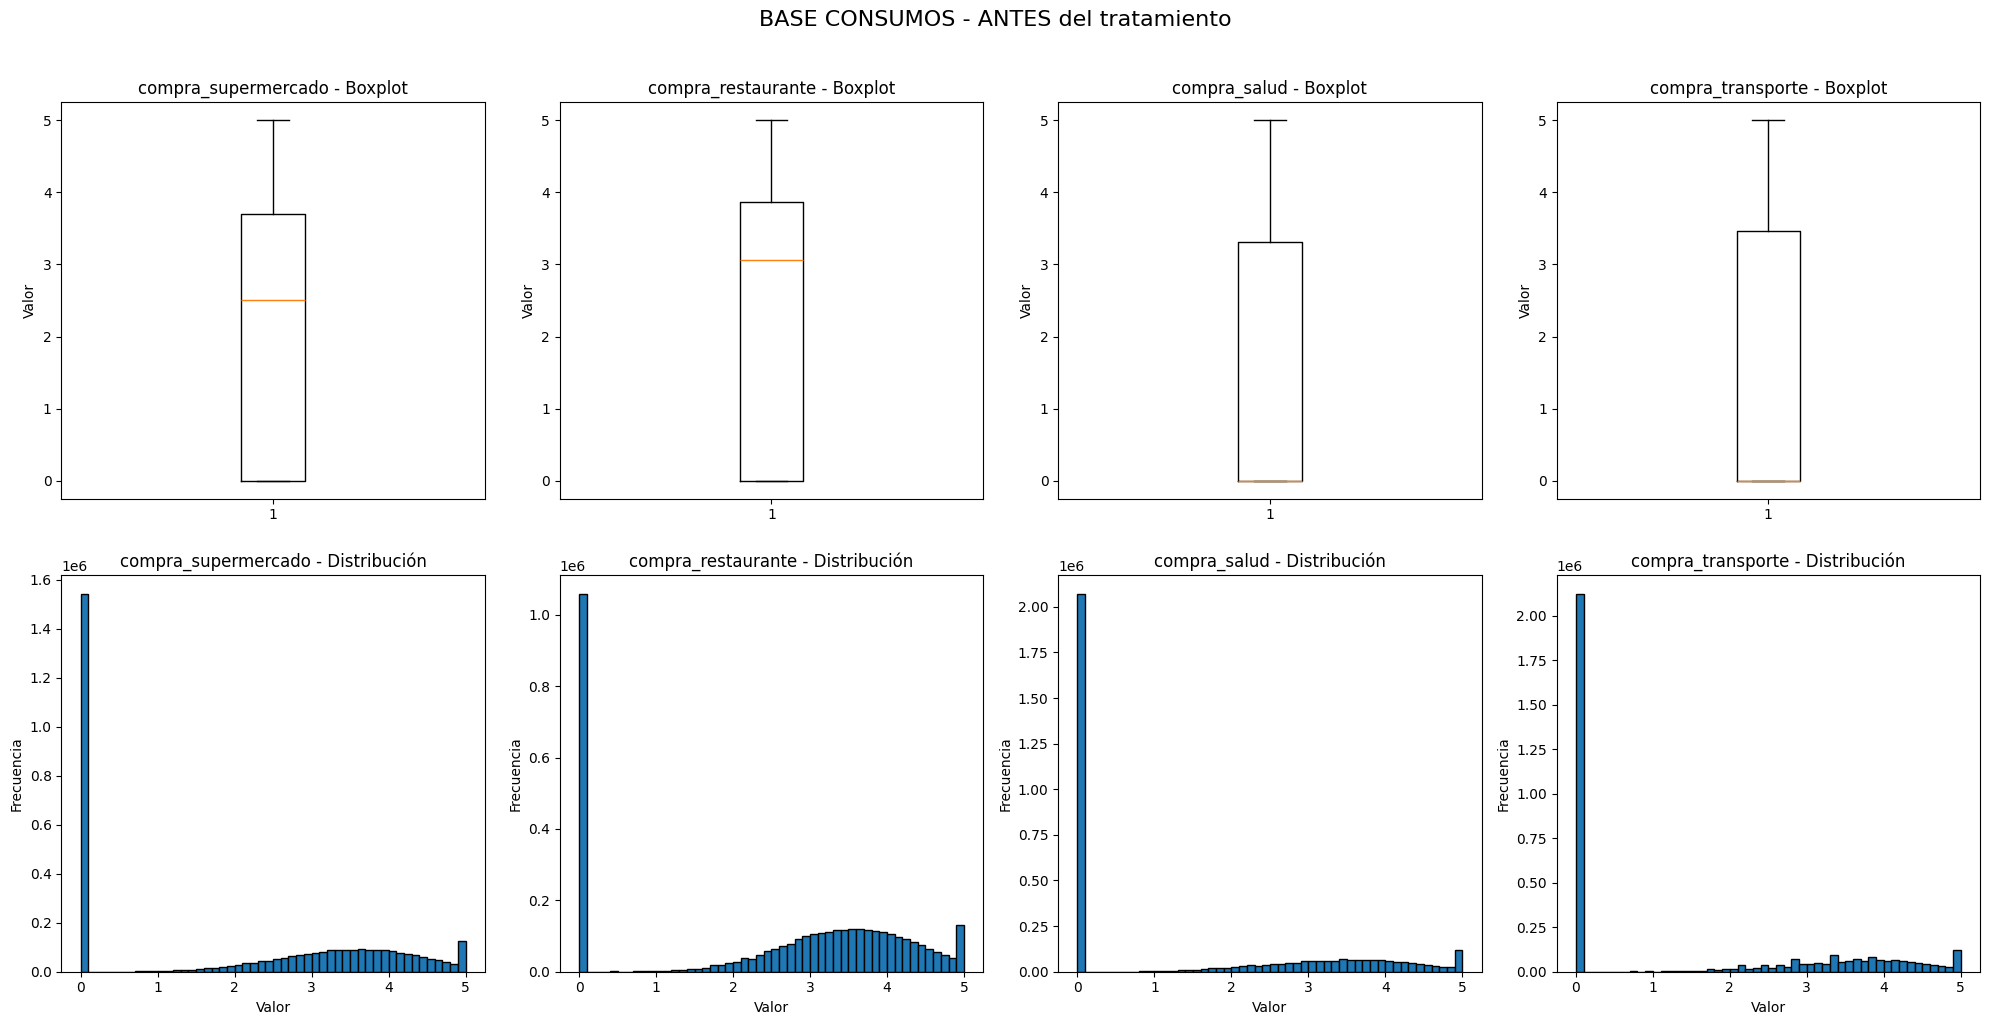


📊 compra_supermercado:
  - Rango normal: [-5.96, 9.93]
  - Outliers detectados: 0 (0.00%)

📊 compra_restaurante:
  - Rango normal: [-5.96, 9.93]
  - Outliers detectados: 0 (0.00%)

📊 compra_salud:
  - Rango normal: [-5.96, 9.93]
  - Outliers detectados: 0 (0.00%)

📊 compra_transporte:
  - Rango normal: [-5.96, 9.93]
  - Outliers detectados: 0 (0.00%)


In [ ]:

visualizar_outliers(base_consumos_fe, bcnum_consumos, "BASE CONSUMOS")
# Reportar outliers
for col in bcnum_consumos:
    outliers_bconsumo, lower_bconsumo, upper_bconsumo = detectar_outliers_iqr(base_consumos, col)
    print(f"\n📊 {col}:")
    print(f"  - Rango normal: [{lower:.2f}, {upper:.2f}]")
    print(f"  - Outliers detectados: {len(outliers_bconsumo)} ({len(outliers_bconsumo)/len(base_consumos)*100:.2f}%)")

### **base_consumos.csv**

  - No se detecta outliers, no hay valores duplicados y tampoco nulos